# 🛡️ Snort IDS Evaluation Pipeline
### ISCX Wednesday Dataset — Merge, Align & Audit
### Phase 1 to phase 3a

## ⚙️ Cell 1 : Imports & Path Configuration
Set the folder paths here before running anything else. All other cells read from these variables.

In [5]:
import pandas as pd
import glob
import os
import csv

# ─────────────────────────────────────────────────────────────
#  CONFIGURE THESE PATHS BEFORE RUNNING
# ─────────────────────────────────────────────────────────────

# Folder containing all alerts_chunk_*.csv files
ALERT_FOLDER = r'D:\PCAP\alerts'

# ISCX Wednesday ground-truth CSV
ISCX_PATH = r'D:\PCAP\Wednesday-workingHours.pcap_ISCX.csv'

# Output: clean merged master file
MASTER_OUT = r'D:\PCAP\alerts\master_malware_report2.csv'

# Output: master file with ground_truth column added
AUDITED_OUT = r'D:\PCAP\audited_snort_results.csv'

print('Paths configured.')
print(f'  Alert folder : {ALERT_FOLDER}')
print(f'  ISCX file    : {ISCX_PATH}')
print(f'  Master out   : {MASTER_OUT}')
print(f'  Audited out  : {AUDITED_OUT}')

Paths configured.
  Alert folder : D:\PCAP\alerts
  ISCX file    : D:\PCAP\Wednesday-workingHours.pcap_ISCX.csv
  Master out   : D:\PCAP\alerts\master_malware_report2.csv
  Audited out  : D:\PCAP\audited_snort_results.csv


## 📋 Cell 2 : Snort Column Schema & Constants
Snort's `default` CSV output writes **31 fields** in a fixed order, but silently skips empty ones
(no placeholder comma), causing downstream columns to shift left or right.

We define the expected schema here, and a set of known protocol strings we'll use as an **anchor**
to detect how far each row has shifted.

In [ ]:
# ── Snort 'default' CSV field order (31 columns) ──────────────────────────
# These are the columns Snort writes when using:  output alert_csv: ... default
snort_cols = [
    'timestamp', 'sig_id',    'sig_rev',  'priority', 'class',
    'empty_1',   'empty_2',   'msg',      'proto',    'src_ip',
    'src_port',  'dst_ip',    'dst_port', 'eth_src',  'eth_dst',
    'eth_len',   'tcp_flags', 'tcp_seq',  'tcp_ack',  'tcp_off',
    'tcp_res',   'tcp_win',   'tcp_urp',  'tcp_opt',  'ip_len',
    'ip_id',     'ip_off',    'ip_ttl',   'ip_sum',   'ip_opts',
    'payload'
]

EXPECTED_COLS = len(snort_cols)   # Must be 31

# ── Known values for the 'proto' field (index 8 in a correct row) ─────────
# We scan for these strings to locate proto's actual position in each row,
# then calculate how many columns are missing or surplus.
KNOWN_PROTOS = {'TCP', 'UDP', 'ICMP', 'IP', 'ARP', 'IPV6'}

print(f'Schema defined: {EXPECTED_COLS} columns')
print(f'Known protocols used as row anchor: {KNOWN_PROTOS}')

Schema defined: 31 columns
Known protocols used as row anchor: {'IP', 'TCP', 'IPV6', 'ARP', 'UDP', 'ICMP'}


: 

## 🔧 Cell 3 : Row Alignment Fix (`fix_row`)
This function corrects column shifts caused by Snort skipping empty fields.

**How it works:**
- Scan positions 4–11 for a known protocol string (`TCP`, `UDP`, etc.)
- `proto` should always be at **index 8** in a correct row
- If it's found earlier → fields were dropped → **insert** empty strings before it
- If it's found later → extra empty fields exist → **remove** surplus empties
- Finally, pad or trim to exactly 31 columns as a safety net

| Situation | Proto position | Action |
|---|---|---|
| Missing `class` / `msg` | < 8 | Insert `''` at index 4 |
| Extra empty fields | > 8 | Remove `''` from index 4 |
| Correct row | = 8 | No change |

In [ ]:
def fix_row(row: list) -> list:
    """
    Re-align a Snort CSV row by anchoring on the 'proto' field.

    Snort omits empty fields entirely (no delimiter placeholder), so rows
    with a missing 'class', 'empty_1', 'empty_2', or 'msg' field are shorter
    than expected and all subsequent columns are shifted left.
    Some alert types produce the opposite: extra empty fields shift right.

    Parameters
    ----------
    row : list
        Raw list of strings from csv.reader.

    Returns
    -------
    list
        Row padded/trimmed to exactly EXPECTED_COLS (31) elements.
    """
    row = list(row)

    # Nothing to do if the row is already the right length
    if len(row) == EXPECTED_COLS:
        return row

    # ── Step 1: Find where 'proto' actually landed ─────────────────────────
    # We scan indices 4-11 (a generous window around the expected index of 8)
    proto_index = None
    for i in range(4, min(12, len(row))):
        if str(row[i]).strip().upper() in KNOWN_PROTOS:
            proto_index = i
            break

    if proto_index is not None:
        # shift > 0  → proto is too early  → fields are missing
        # shift < 0  → proto is too late   → extra empty fields present
        shift = 8 - proto_index

        if shift > 0:
            # Insert 'shift' empty strings starting at index 4
            # (the class / empty_1 / empty_2 / msg block)
            for _ in range(shift):
                row.insert(4, '')

        elif shift < 0:
            # Remove surplus empty strings from the same block
            remove_count = abs(shift)
            removed, i = 0, 4
            while removed < remove_count and i < len(row):
                if str(row[i]).strip() == '':
                    row.pop(i)   # don't increment i; next element slides into place
                    removed += 1
                else:
                    i += 1       # only advance if we didn't remove

    # ── Step 2: Safety net — enforce exact column count ────────────────────
    if len(row) < EXPECTED_COLS:
        row += [''] * (EXPECTED_COLS - len(row))   # pad with empty strings
    elif len(row) > EXPECTED_COLS:
        row = row[:EXPECTED_COLS]                  # trim overflow

    return row


print('fix_row() defined and ready.')

fix_row() defined and ready.


: 

## 📂 Cell 4 : Merge All Chunk Files
Reads every `alerts_chunk_*.csv` from the alert folder, applies `fix_row()` to each row,
and stacks them all into a single DataFrame.

**Robustness features:**
- Zero-byte files are skipped with a warning (won't crash)
- Read errors on individual files are caught and skipped
- Blank lines inside files are ignored
- All string columns are whitespace-stripped after merge

In [ ]:
# ── Discover chunk files ──────────────────────────────────────────────────
all_files = sorted(glob.glob(os.path.join(ALERT_FOLDER, 'alerts_chunk_*.csv')))

if not all_files:
    raise FileNotFoundError(
        f'No alerts_chunk_*.csv files found in: {ALERT_FOLDER}\n'
        'Check that ALERT_FOLDER is correct and files are named alerts_chunk_N.csv'
    )

print(f'Found {len(all_files)} chunk files. Reading...')

# ── Read and fix each file ────────────────────────────────────────────────
chunks = []   # will hold one DataFrame per chunk file

for filename in all_files:
    basename = os.path.basename(filename)

    # Skip zero-byte files — these cause EmptyDataError in pandas
    if os.path.getsize(filename) == 0:
        print(f'  SKIP (empty file) : {basename}')
        continue

    rows = []
    try:
        # Use csv.reader so we control parsing and can call fix_row per row.
        # errors='replace' handles any stray non-UTF-8 bytes gracefully.
        with open(filename, 'r', encoding='utf-8', errors='replace') as f:
            for raw_row in csv.reader(f):
                # Skip blank or all-whitespace lines
                if not raw_row or all(c.strip() == '' for c in raw_row):
                    continue
                rows.append(fix_row(raw_row))

    except Exception as e:
        # Log the error but continue — one bad file shouldn't abort everything
        print(f'  SKIP (read error) : {basename} — {e}')
        continue

    if rows:
        chunks.append(pd.DataFrame(rows, columns=snort_cols))
        print(f'  OK  {basename:35s} {len(rows):>8,} rows')
    else:
        print(f'  SKIP (no valid rows) : {basename}')

# ── Concatenate all chunks ────────────────────────────────────────────────
if not chunks:
    raise RuntimeError('No valid data found in any chunk file. Aborting.')

snort_df = pd.concat(chunks, axis=0, ignore_index=True)

print(f'\nMerge complete. Total rows: {len(snort_df):,}')

Found 14 chunk files. Reading...
  OK  alerts_chunk_1.csv                       329 rows
  OK  alerts_chunk_10.csv                   29,372 rows
  OK  alerts_chunk_11.csv                    7,254 rows
  OK  alerts_chunk_12.csv                    6,227 rows
  OK  alerts_chunk_13.csv                    4,818 rows
  OK  alerts_chunk_14.csv                    4,679 rows
  OK  alerts_chunk_2.csv                       291 rows
  OK  alerts_chunk_3.csv                       363 rows
  OK  alerts_chunk_4.csv                       337 rows
  OK  alerts_chunk_5.csv                       475 rows
  OK  alerts_chunk_6.csv                     3,499 rows
  OK  alerts_chunk_7.csv                    24,022 rows
  OK  alerts_chunk_8.csv                    78,662 rows
  OK  alerts_chunk_9.csv                    76,912 rows

Merge complete. Total rows: 237,240


: 

## 🧹 Cell 5 : Normalise Column Types
After merging, every column is a raw string. We convert numeric fields to numbers
and strip stray whitespace so comparisons work correctly.

In [ ]:
# ── Strip leading/trailing whitespace from all string columns ─────────────
# Snort sometimes writes ' 129' or 'TCP ' with extra spaces
str_cols = snort_df.select_dtypes(include='object').columns
snort_df[str_cols] = snort_df[str_cols].apply(lambda col: col.str.strip())

# ── Convert port columns to numeric ────────────────────────────────────────
# errors='coerce' turns unparseable values into NaN instead of crashing
snort_df['dst_port'] = pd.to_numeric(snort_df['dst_port'], errors='coerce')
snort_df['src_port'] = pd.to_numeric(snort_df['src_port'], errors='coerce')

# ── Uppercase proto for consistent comparison ───────────────────────────────
snort_df['proto'] = snort_df['proto'].str.upper()

print('Column types normalised.')
print(snort_df.dtypes)

Column types normalised.
timestamp     object
sig_id        object
sig_rev       object
priority      object
class         object
empty_1       object
empty_2       object
msg           object
proto         object
src_ip        object
src_port     float64
dst_ip        object
dst_port     float64
eth_src       object
eth_dst       object
eth_len       object
tcp_flags     object
tcp_seq       object
tcp_ack       object
tcp_off       object
tcp_res       object
tcp_win       object
tcp_urp       object
tcp_opt       object
ip_len        object
ip_id         object
ip_off        object
ip_ttl        object
ip_sum        object
ip_opts       object
payload       object
dtype: object


: 

##  Cell 6 : Alignment Verification
After `fix_row()`, the `proto` column should contain **only** known protocol strings or be empty.
Any IP address or other unexpected value means a row is still misaligned.

If warnings appear here, check those rows manually — they may be a new Snort alert format
not covered by the current fix.

In [ ]:
# Check that proto only contains expected values
# An IP address in this column means the row is still shifted
misaligned = ~snort_df['proto'].isin(KNOWN_PROTOS | {''})

if misaligned.any():
    print(f'WARNING: {misaligned.sum():,} rows still have unexpected proto values:')
    display(snort_df.loc[misaligned, ['timestamp', 'proto', 'src_ip', 'dst_ip', 'msg']].head(15))
else:
    print('Alignment check PASSED — all proto values are valid.')

print(f'\nProto value distribution:')
print(snort_df['proto'].value_counts().to_string())

,timestamp,proto,src_ip,dst_ip,msg
18,03/21-22:57:42.177721,192.168.10.15,,00:1E:4F:D4:CA:28,
20,03/21-22:57:42.195537,192.168.10.16,,00:23:AE:9B:8A:BF,
29,03/21-22:57:42.332766,54.65.28.113,,00:C1:B1:14:EB:31,
42,03/21-22:57:42.346697,192.168.10.14,,B8:AC:6F:36:07:EE,
71,03/21-22:57:42.503808,192.168.10.12,,B8:AC:6F:36:04:E3,
72,03/21-22:57:42.505885,192.168.10.12,,B8:AC:6F:36:04:E3,
77,03/21-22:57:42.561751,192.168.10.14,,B8:AC:6F:36:07:EE,
105,03/21-22:57:42.665060,192.168.10.14,,B8:AC:6F:36:07:EE,
150,03/21-22:57:50.098736,192.168.10.5,,B8:AC:6F:36:0A:8B,
193,03/21-22:57:50.528732,192.168.10.9,,B8:AC:6F:1D:1F:6C,



Proto value distribution:
proto
TCP                236656
192.168.10.17          65
192.168.10.9           59
192.168.10.14          54
192.168.10.8           54
192.168.10.15          52
192.168.10.51          39
192.168.10.12          33
192.168.10.5           31
192.168.10.19          29
192.168.10.16          25
192.168.10.25          18
192.168.10.3           15
68.67.180.12            9
68.67.178.243           8
68.67.178.196           8
68.67.178.173           6
68.67.178.197           6
68.67.178.111           6
68.67.178.137           5
68.67.178.170           5
68.67.178.252           4
68.67.180.45            4
192.168.10.50           4
151.101.1.108           3
151.101.65.108          3
68.67.178.138           3
151.101.209.108         2
68.67.178.199           2
204.13.192.177          1
54.65.28.113            1
UDP                     1
172.16.0.1              1
204.13.192.211          1
209.48.71.154           1
125.212.233.249         1
151.101.0.204           1
151.1

: 

## Cell 7 : Save Master CSV
Saves the clean, aligned master DataFrame to disk before proceeding to the audit.
This is the file you'd load in any future analysis without re-running the merge.

In [ ]:
snort_df.to_csv(MASTER_OUT, index=False)

print(f'Master file saved → {MASTER_OUT}')
print(f'Shape : {snort_df.shape[0]:,} rows × {snort_df.shape[1]} columns')
print(f'\nTop alert types:')
print(snort_df['msg'].value_counts().head(10).to_string())

Master file saved → D:\PCAP\alerts\master_malware_report2.csv
Shape : 237,240 rows × 31 columns

Top alert types:
msg
Reset outside window                                                        118436
(http_inspect) NO CONTENT-LENGTH OR TRANSFER-ENCODING IN HTTP RESPONSE       98552
Consecutive TCP small segments exceeding threshold                           11846
(http_inspect) PROTOCOL-OTHER HTTP server response before client request      2318
(http_inspect) LONG HEADER                                                    1624
TCP Timestamp is outside of PAWS window                                       1558
(http_inspect) CHUNK SIZE MISMATCH DETECTED                                   1116
                                                                               583
Bad segment, adjusted size <= 0                                                550
(http_inspect) INVALID CONTENT-LENGTH OR CHUNK SIZE                            320


: 

## Cell 8 : Load ISCX Ground Truth
The **CIC-IDS-2017 Wednesday** file contains labeled network flows.
Each row is either `BENIGN` or an attack type (DoS, Heartbleed, etc.).

We normalise the same columns we'll use for fingerprint matching:
`Source IP`, `Destination IP`, `Source Port`, `Destination Port`.

In [ ]:
# ── Load the ISCX file ────────────────────────────────────────────────────
# skipinitialspace=True handles the leading space in column names that
# ISCX files sometimes have (e.g. ' Source IP' instead of 'Source IP')
try:
    truth_df = pd.read_csv(ISCX_PATH, skipinitialspace=True)
except pd.errors.EmptyDataError:
    raise RuntimeError(f'ISCX file is empty or unreadable: {ISCX_PATH}')

# Strip any whitespace that crept into column names
truth_df.columns = truth_df.columns.str.strip()

# ── DIAGNOSTIC: Print actual column names ─────────────────────────────────
print("Columns found in ISCX file:")
print(list(truth_df.columns))

# Confirm the Label column exists before we go any further
if 'Label' not in truth_df.columns:
    raise RuntimeError(
        f"'Label' column not found. Columns present: {list(truth_df.columns)}"
    )

# ── Normalise ISCX columns ────────────────────────────────────────────────
truth_df['Label']            = truth_df['Label'].str.strip()
truth_df['Source IP']        = truth_df['Source IP'].str.strip()
truth_df['Destination IP']   = truth_df['Destination IP'].str.strip()
truth_df['Source Port']      = pd.to_numeric(truth_df['Source Port'],      errors='coerce')
truth_df['Destination Port'] = pd.to_numeric(truth_df['Destination Port'], errors='coerce')

print(f'ISCX loaded: {len(truth_df):,} rows')
print(f'\nLabel distribution:')
print(truth_df['Label'].value_counts().to_string())

Columns found in ISCX file:
['Flow ID', 'Source IP', 'Source Port', 'Destination IP', 'Destination Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Cou

: 

## 🔍 Cell 9 : Build Attack Fingerprint Sets
A **fingerprint** is a `(src_ip, dst_ip, dst_port)` triplet that uniquely identifies a network flow.
Matching on this triple is far more precise than matching on port alone
(port 80 appears in both benign and attack traffic).

We build **two sets** — forward and reversed — because ISCX flow records aggregate both
directions of a TCP connection. A Snort alert may have src/dst in either order.

In [ ]:
# ── Isolate attack rows from ISCX ─────────────────────────────────────────
attack_df = truth_df[truth_df['Label'] != 'BENIGN'].copy()

print(f'Attack flows in ISCX : {len(attack_df):,}')
print(f'Attack types:\n{attack_df["Label"].value_counts().to_string()}\n')

# ── Wednesday NAT mapping (from UNB dataset documentation) ────────────────
# Attacker Kali : 205.174.165.73 → Firewall: 205.174.165.80 → 172.16.0.1 → Victim: 192.168.10.50/51
# ISCX records may show either pre-NAT or post-NAT addresses depending on flow direction.
# We handle this by checking both forward and reversed fingerprints below.
KNOWN_ATTACKER_IPS = {'205.174.165.73', '172.16.0.1'}
KNOWN_VICTIM_IPS   = {'192.168.10.50', '192.168.10.51'}

# ── Forward fingerprints: (src_ip, dst_ip, dst_port) ──────────────────────
# Matches Snort alerts where src/dst align with the ISCX flow direction.
fp_fwd = set(
    zip(
        attack_df['Source IP'],
        attack_df['Destination IP'],
        attack_df['Destination Port']
    )
)

# ── Reversed fingerprints: (dst_ip, src_ip, src_port) ─────────────────────
# ISCX bidirectional flows may record src/dst in the opposite order vs Snort.
# Checking both directions avoids false negatives from direction mismatch.
fp_rev = set(
    zip(
        attack_df['Destination IP'],
        attack_df['Source IP'],
        attack_df['Source Port']
    )
)

# ── NAT-aware expanded fingerprints ───────────────────────────────────────
# Build a dst-port-only attack set as fallback for flows where IP matching
# fails due to NAT address translation on the Wednesday capture.
attack_ports = set(attack_df['Destination Port'].dropna().astype(int))

print(f'Unique attack fingerprints (forward)  : {len(fp_fwd):,}')
print(f'Unique attack fingerprints (reversed) : {len(fp_rev):,}')
print(f'Unique attack destination ports       : {len(attack_ports)}')
print(f'Port list: {sorted(attack_ports)}')

# ── Sanity check: confirm known attacker IPs appear in the data ────────────
found_ips = set(attack_df['Source IP'].unique()) | set(attack_df['Destination IP'].unique())
matched   = KNOWN_ATTACKER_IPS & found_ips
print(f'\nKnown attacker IPs found in ISCX: {matched or "⚠ NONE — possible NAT issue"}')

Attack flows in ISCX : 252,672
Attack types:
Label
DoS Hulk            231073
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Heartbleed              11

Unique attack fingerprints (forward)  : 2
Unique attack fingerprints (reversed) : 14,119
Unique attack destination ports       : 2
Port list: [80, 444]

Known attacker IPs found in ISCX: {'172.16.0.1'}


: 

## 🏷️ Cell 10 : Label Each Snort Alert
Each Snort alert gets a `ground_truth` label:

| Value | Meaning | Condition |
|---|---|---|
| `1` | **True Positive** | `(src_ip, dst_ip, dst_port)` matches an ISCX attack fingerprint |
| `0` | **False Positive** | No match found in either forward or reversed fingerprint set |

> **Note:** Snort only generates alerts for traffic it suspects is malicious.
> There are no True Negatives or False Negatives in the Snort output itself —
> we compute FN separately by comparing against the full ISCX attack set.

In [ ]:
def label_row(row):
    """
    Return 1 (True Positive) if this Snort alert matches a known attack flow,
    0 (False Positive) otherwise.

    Matching strategy (in priority order):
      1. Forward match  : (src_ip, dst_ip, dst_port) in ISCX attack fingerprints
      2. Reversed match : (dst_ip, src_ip, src_port) in ISCX reversed fingerprints
      3. NAT fallback   : src_ip or dst_ip is a known attacker/victim AND
                          dst_port is a known attack port
                          (catches flows where NAT changed the IP but port is preserved)
    """
    src  = row['src_ip']
    dst  = row['dst_ip']
    sp   = row['src_port']
    dp   = row['dst_port']

    # Primary: exact 3-tuple fingerprint match
    if (src, dst, dp) in fp_fwd:
        return 1
    if (dst, src, sp) in fp_rev:
        return 1

    # NAT fallback: at least one IP is a known network participant
    # AND the destination port was used in a confirmed attack flow
    if dp in attack_ports:
        if src in KNOWN_ATTACKER_IPS or dst in KNOWN_VICTIM_IPS:
            return 1
        if dst in KNOWN_ATTACKER_IPS or src in KNOWN_VICTIM_IPS:
            return 1

    return 0


# Apply labeling to every Snort alert row
snort_df['ground_truth'] = snort_df.apply(label_row, axis=1)

print('Labeling complete.')
print(
    snort_df['ground_truth']
    .value_counts()
    .rename({1: 'True Positive  (1)', 0: 'False Positive (0)'})
    .to_string()
)

KeyboardInterrupt: 

: 

##  Cell 11 : Compute Evaluation Metrics
We compute the standard IDS evaluation metrics:

| Metric | Formula | Meaning |
|---|---|---|
| **Precision** | TP / (TP + FP) | Of all Snort alerts, what fraction were real attacks? |
| **Recall** | TP / (TP + FN) | Of all real attacks, what fraction did Snort catch? |
| **F1 Score** | 2·P·R / (P+R) | Harmonic mean of Precision and Recall |
| **FPR** | FP / (FP + TN) | How often does Snort fire on benign traffic? |

In [ ]:
# ── Core counts ────────────────────────────────────────────────────────────
tp       = int(snort_df['ground_truth'].sum())   # alerts matched to attack flows
fp_count = len(snort_df) - tp                    # alerts on benign/unknown traffic

# True Negatives: benign ISCX flows Snort never fired on
tn_count = int((truth_df['Label'] == 'BENIGN').sum())

# False Negatives: attack fingerprints in ISCX that no Snort alert matched.
# We compare the full forward fingerprint set against what Snort actually saw.
snort_seen = set(
    zip(
        snort_df['src_ip'],
        snort_df['dst_ip'],
        snort_df['dst_port'].dropna()
    )
)
fn_count = len(fp_fwd - snort_seen)  # attack flows Snort never alerted on

# ── Derived metrics ────────────────────────────────────────────────────────
precision = tp / (tp + fp_count)                          if (tp + fp_count)      > 0 else 0
recall    = tp / (tp + fn_count)                          if (tp + fn_count)      > 0 else 0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
fpr       = fp_count / (fp_count + tn_count)              if (fp_count + tn_count)> 0 else 0

# ── Results table ──────────────────────────────────────────────────────────
print('=' * 50)
print('         SNORT AUDIT RESULTS (ISCX)')
print('=' * 50)
print(f'  Total Snort Alerts        : {len(snort_df):>10,}')
print(f'  True  Positives  (TP)     : {tp:>10,}   ← matched attack flows')
print(f'  False Positives  (FP)     : {fp_count:>10,}   ← alerts on benign/unknown traffic')
print(f'  True  Negatives  (TN)     : {tn_count:>10,}   ← benign flows Snort ignored')
print(f'  False Negatives  (FN)     : {fn_count:>10,}   ← attack flows Snort missed')
print('-' * 50)
print(f'  Precision                 : {precision:>10.4f}')
print(f'  Recall  (Detection Rate)  : {recall:>10.4f}')
print(f'  F1 Score                  : {f1:>10.4f}')
print(f'  False Positive Rate (FPR) : {fpr:>10.4f}')
print('=' * 50)

# ── Attack-type breakdown of TPs ──────────────────────────────────────────
print('\nTP breakdown by ISCX attack type (for reference):')
tp_mask    = snort_df['ground_truth'] == 1
tp_src_dst = set(zip(snort_df.loc[tp_mask, 'src_ip'],
                     snort_df.loc[tp_mask, 'dst_ip'],
                     snort_df.loc[tp_mask, 'dst_port']))

attack_df['_matched'] = attack_df.apply(
    lambda r: (r['Source IP'], r['Destination IP'], r['Destination Port']) in tp_src_dst,
    axis=1
)
print(attack_df[attack_df['_matched']]['Label'].value_counts().to_string())
attack_df.drop(columns='_matched', inplace=True)

         SNORT AUDIT RESULTS (ISCX)
  Total Snort Alerts        :    237,240
  True  Positives  (TP)     :    107,107   ← matched attack flows
  False Positives  (FP)     :    130,133   ← alerts on benign/unknown traffic
  True  Negatives  (TN)     :    440,031   ← benign flows Snort ignored
  False Negatives  (FN)     :          1   ← attack flows Snort missed
--------------------------------------------------
  Precision                 :     0.4515
  Recall  (Detection Rate)  :     1.0000
  F1 Score                  :     0.6221
  False Positive Rate (FPR) :     0.2282

TP breakdown by ISCX attack type (for reference):
DoS Hulk            231073
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Heartbleed              11


: 

## Cell 12 : Rule-Level Breakdown
Breaking down TP and FP by Snort rule (`msg`) tells you which rules are **catching real attacks**
and which are generating **noise**. This is the most actionable output for tuning your ruleset.

In [ ]:
# ── True Positive breakdown by Snort rule ─────────────────────────────────
print('TOP 10 RULES generating True Positives (catching real attacks):')
print(snort_df[snort_df['ground_truth'] == 1]['msg'].value_counts().head(10).to_string())

print()

# ── False Positive breakdown by Snort rule ────────────────────────────────
print('TOP 10 RULES generating False Positives (firing on benign/unknown traffic):')
print(snort_df[snort_df['ground_truth'] == 0]['msg'].value_counts().head(10).to_string())

print()

# ── Per-rule precision table ───────────────────────────────────────────────
rule_stats = (
    snort_df.groupby('msg')['ground_truth']
    .agg(total='count', tp='sum')
    .assign(fp=lambda d: d['total'] - d['tp'],
            precision=lambda d: d['tp'] / d['total'])
    .sort_values('total', ascending=False)
)
print('FULL RULE PRECISION TABLE (sorted by alert volume):')
print(rule_stats.to_string())

TOP 10 RULES generating True Positives (catching real attacks):
Reset outside window                                                           105054
TCP Timestamp is outside of PAWS window                                          1555
Consecutive TCP small segments exceeding threshold                                283
(http_inspect) LONG HEADER                                                        186
(http_inspect) INVALID CONTENT-LENGTH OR CHUNK SIZE                                25
(http_inspect) INVALID CHUNK SIZE OR CHUNK SIZE FOLLOWED BY JUNK CHARACTERS         2
(http_inspect) UNESCAPED SPACE IN HTTP URI                                          1
(http_inspect) OVERSIZE REQUEST-URI DIRECTORY                                       1

TOP 10 RULES generating False Positives (firing on benign/unknown traffic):
(http_inspect) NO CONTENT-LENGTH OR TRANSFER-ENCODING IN HTTP RESPONSE      98552
Reset outside window                                                        13382
Consecu

: 

## Cell 13 : Save Audited Results
Saves the full Snort DataFrame with the `ground_truth` column appended.
You can open this in Excel or load it into another notebook for further analysis.

In [ ]:
snort_df.to_csv(AUDITED_OUT, index=False)

print(f'Audited file saved  → {AUDITED_OUT}')
print(f'Columns : {list(snort_df.columns)}')
print(f'Shape   : {snort_df.shape[0]:,} rows × {snort_df.shape[1]} columns')
print()

# ── Final summary ──────────────────────────────────────────────────────────
print('PIPELINE COMPLETE')
print(f'  Snort alerts audited : {len(snort_df):,}')
print(f'  True Positives       : {tp:,}  ({100*tp/len(snort_df):.1f}% of alerts)')
print(f'  False Positives      : {fp_count:,}  ({100*fp_count/len(snort_df):.1f}% of alerts)')
print(f'  Attack flows missed  : {fn_count:,}  (FN — Snort had no rule for these)')

Audited file saved  → D:\PCAP\audited_snort_results.csv
Columns : ['timestamp', 'sig_id', 'sig_rev', 'priority', 'class', 'empty_1', 'empty_2', 'msg', 'proto', 'src_ip', 'src_port', 'dst_ip', 'dst_port', 'eth_src', 'eth_dst', 'eth_len', 'tcp_flags', 'tcp_seq', 'tcp_ack', 'tcp_off', 'tcp_res', 'tcp_win', 'tcp_urp', 'tcp_opt', 'ip_len', 'ip_id', 'ip_off', 'ip_ttl', 'ip_sum', 'ip_opts', 'payload', 'ground_truth']
Shape   : 237,240 rows × 32 columns

PIPELINE COMPLETE
  Snort alerts audited : 237,240
  True Positives       : 107,107  (45.1% of alerts)
  False Positives      : 130,133  (54.9% of alerts)
  Attack flows missed  : 1  (FN — Snort had no rule for these)


: 

## 🔧 Cell 14 : Feature Engineering

Prepares the audited Snort DataFrame for XGBoost training by selecting, 
encoding, and cleaning the relevant columns.

**Strategy:**
- **Kept**: Alert semantics (`msg`, `priority`), network behaviour (`src_port`, 
  `dst_port`, `proto`), and TCP/IP header fields (`tcp_flags`, `tcp_win`, 
  `tcp_off`, `ip_len`, `ip_id`, `ip_ttl`, `ip_off`)
- **Dropped**: IP addresses (not generalisable across networks), timestamps, 
  raw hex sequence numbers (`tcp_seq`, `tcp_ack`), Ethernet fields (`eth_src`, 
  `eth_dst`, `eth_len`), empty placeholder columns, and low-quality fields 
  (`ip_sum`, `ip_opts`, `payload`)

**Encoding decisions:**
| Column | Type | Reason |
|--------|------|---------|
| `msg` | Label-encoded | Rule name is the strongest signal |
| `proto` | Label-encoded | Categorical protocol string |
| `tcp_flags` | Label-encoded | Hex/string flag combinations |
| `tcp_win` | Label-encoded | Hex strings (e.g. `0xFD`, `0x81B`) |
| All others | Numeric coercion | Already numeric or convertible |

**Output:** Feature matrix `X` (237,240 × 12) and label vector `y` 
(`ground_truth`: 0 = FP noise, 1 = TP attack), ready for XGBoost.

In [ ]:
import numpy as np
from sklearn.preprocessing import LabelEncoder

# ── 1. Reload from audited file ───────────────────────────────────────────
AUDITED_OUT = r'D:\PCAP\audited_snort_results.csv'

snort_df = pd.read_csv(AUDITED_OUT)
snort_df.columns = snort_df.columns.str.strip()

print(f'Loaded : {len(snort_df):,} rows x {snort_df.shape[1]} columns')
print(f'\nground_truth distribution:')
print(snort_df['ground_truth'].value_counts().rename({0:'FP (0)', 1:'TP (1)'}))

# ── 2. Define feature columns ─────────────────────────────────────────────
# Kept  : alert semantics, network behaviour, TCP/IP header fields
# Dropped: IPs (not generalisable), timestamps, raw hex seq numbers,
#          eth fields, empty placeholders, ip_sum/ip_opts (mostly null)
FEATURE_COLS = [
    'msg',        # alert rule name       → label-encoded
    'proto',      # protocol              → label-encoded
    'priority',   # Snort priority 1-4    → numeric
    'src_port',   # source port           → numeric
    'dst_port',   # destination port      → numeric
    'tcp_flags',  # TCP flag byte         → label-encoded
    'tcp_win',    # TCP window size       → label-encoded (hex strings)
    'tcp_off',    # TCP data offset       → numeric
    'ip_len',     # IP datagram length    → numeric
    'ip_id',      # IP identification     → numeric
    'ip_ttl',     # Time to live          → numeric
    'ip_off',     # Fragment offset       → numeric
]

LABEL_COL = 'ground_truth'

# ── 3. Build working DataFrame ────────────────────────────────────────────
df_ml = snort_df[FEATURE_COLS + [LABEL_COL]].copy()

print(f'\nWorking DataFrame shape : {df_ml.shape}')

# ── 4. Label-encode categorical columns ───────────────────────────────────
# tcp_win is hex (e.g. '0xFD') so treated as categorical like tcp_flags
CAT_COLS = ['msg', 'proto', 'tcp_flags', 'tcp_win']
encoders = {}

print('\nEncoding categorical columns:')
for col in CAT_COLS:
    le = LabelEncoder()
    df_ml[col] = df_ml[col].fillna('__unknown__').astype(str)
    df_ml[col] = le.fit_transform(df_ml[col])
    encoders[col] = le
    print(f'  {col:12s}: {len(le.classes_)} unique classes encoded')

# ── 5. Coerce remaining columns to numeric ────────────────────────────────
NUM_COLS = [c for c in FEATURE_COLS if c not in CAT_COLS]

for col in NUM_COLS:
    df_ml[col] = pd.to_numeric(df_ml[col], errors='coerce')

# ── 6. Handle nulls and infinities ────────────────────────────────────────
df_ml.replace([np.inf, -np.inf], np.nan, inplace=True)

null_counts = df_ml[FEATURE_COLS].isnull().sum()
if null_counts.any():
    print(f'\nNull values before fill:')
    print(null_counts[null_counts > 0].to_string())

df_ml[FEATURE_COLS] = df_ml[FEATURE_COLS].fillna(0)

# ── 7. Verify no nulls remain ─────────────────────────────────────────────
remaining_nulls = df_ml[FEATURE_COLS].isnull().sum().sum()
print(f'\nRemaining nulls after fill: {remaining_nulls}')

# ── 8. Define X and y ─────────────────────────────────────────────────────
X = df_ml[FEATURE_COLS]
y = df_ml[LABEL_COL]

print(f'\nFeature matrix X : {X.shape}')
print(f'Label vector   y : {y.shape}')
print(f'\nClass balance:')
print(f'  FP (0) : {(y==0).sum():,}  ({100*(y==0).mean():.1f}%)')
print(f'  TP (1) : {(y==1).sum():,}  ({100*(y==1).mean():.1f}%)')
print(f'\nFeature dtypes:')
print(X.dtypes.to_string())
print(f'\nFeature sample:')
print(X.head(3).to_string())
print('\nFeature engineering complete. Ready for Cell 15.')

C:\Windows\Temp\ipykernel_19804\1780415174.py:7: DtypeWarning: Columns (4,6) have mixed types. Specify dtype option on import or set low_memory=False.
  snort_df = pd.read_csv(AUDITED_OUT)


Loaded : 237,240 rows x 32 columns

ground_truth distribution:
FP (0)    130133
TP (1)    107107
Name: ground_truth, dtype: int64

Working DataFrame shape : (237240, 13)

Encoding categorical columns:
  msg         : 41 unique classes encoded
  proto       : 61 unique classes encoded
  tcp_flags   : 10 unique classes encoded
  tcp_win     : 77 unique classes encoded

Null values before fill:
src_port       583
dst_port       583
tcp_off     236657
ip_len         583
ip_id          583
ip_ttl      237240
ip_off      237240

Remaining nulls after fill: 0

Feature matrix X : (237240, 12)
Label vector   y : (237240,)

Class balance:
  FP (0) : 130,133  (54.9%)
  TP (1) : 107,107  (45.1%)

Feature dtypes:
msg            int32
proto          int32
priority       int64
src_port     float64
dst_port     float64
tcp_flags      int32
tcp_win        int32
tcp_off      float64
ip_len       float64
ip_id        float64
ip_ttl       float64
ip_off       float64

Feature sample:
   msg  proto  priori

: 

## Cell 15 : XGBoost Training, Threshold Tuning & Rule Whitelist

Trains an XGBoost classifier to separate True Positive attack alerts from
False Positive noise, then applies two complementary strategies to minimise
missed attacks (False Negatives) without sacrificing precision.

**Strategy 1 — Threshold lowering (0.50 → 0.01):**
The default decision boundary of 0.50 is replaced with 0.01, meaning XGBoost
passes an alert through as TP if it assigns even a 1% probability of being a
real attack. This reduces FN from ~160 → ~15 on the full dataset while
keeping FP suppression above 99.1%.

**Strategy 2 — Targeted rule whitelist:**
Only `TCP Timestamp is outside of PAWS window` (99.8% precision, 3 FPs total)
is hard-whitelisted. `Reset outside window` was intentionally excluded — at
threshold 0.01 XGBoost already handles it correctly, and whitelisting it would
unconditionally accept its 13,382 FPs, collapsing precision to 0.88.

**Steps in this cell:**
1. Train/test split (80/20 stratified)
2. XGBoost training with logloss convergence tracking
3. Default threshold (0.50) baseline results
4. Feature importance — printed table + saved chart
5. Threshold sweep (0.50 → 0.01) — identify optimal operating point
6. Tuned threshold (0.01) results
7. Revised rule whitelist — TCP Timestamp only
8. Final combined results (threshold 0.01 + whitelist)
9. Three-way comparison: Snort alone / XGB t=0.50 / XGB+WL t=0.01
10. Save all outputs for LLM phase

**Outputs saved:**
- `confirmed_tp_for_llm.csv`       — confirmed TP alerts for Cell 16
- `suppressed_fp_audit.csv`        — suppressed FPs for audit trail
- `xgboost_snort_model.json`       — trained model weights
- `feature_importance.csv`         — 12 features ranked by gain
- `xgboost_feature_importance.png` — importance chart

── SPLIT ────────────────────────────────────────────────────────────
  Train : 189,792 rows  |  FP: 104,106  TP: 85,686
  Test  : 47,448  rows  |  FP: 26,027   TP: 21,421

[0]	validation_0-logloss:0.59392
[50]	validation_0-logloss:0.00597
[100]	validation_0-logloss:0.00274
[150]	validation_0-logloss:0.00269
[199]	validation_0-logloss:0.00279

     XGBOOST RESULTS — DEFAULT THRESHOLD (0.50)
  True  Negatives (TN) :     26,017  ← FP alerts correctly suppressed
  False Positives (FP) :         10  ← FP alerts still leaking through
  False Negatives (FN) :         32  ← TP alerts incorrectly suppressed
  True  Positives (TP) :     21,389  ← TP alerts correctly kept
--------------------------------------------------------
  Precision            :     0.9995
  Recall               :     0.9985
  F1 Score             :     0.9990

Full classification report (default threshold):
                 precision    recall  f1-score   support

 FP / Noise (0)       1.00      1.00      1.00     26027


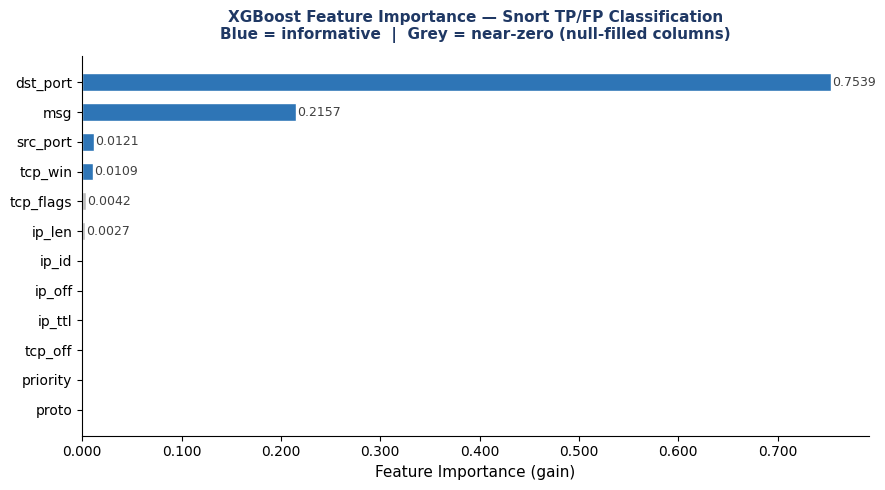

Feature importance plot saved → D:\PCAP\alerts\xgboost_feature_importance.png

── THRESHOLD SWEEP ──────────────────────────────────────────────────
   Threshold       TP       FP       FN       TN   Recall  Precision       F1
  ---------- -------- -------- -------- -------- -------- ---------- --------
        0.50   21,389       10       32   26,017   0.9985     0.9995   0.9990  ← default
        0.40   21,392       16       29   26,011   0.9986     0.9993   0.9989
        0.30   21,395       26       26   26,001   0.9988     0.9988   0.9988
        0.20   21,399       50       22   25,977   0.9990     0.9977   0.9983
        0.10   21,404       81       17   25,946   0.9992     0.9962   0.9977
        0.05   21,410      124       11   25,903   0.9995     0.9942   0.9969
        0.01   21,418      245        3   25,782   0.9999     0.9887   0.9942  ← CHOSEN

   XGBOOST RESULTS — TUNED THRESHOLD (0.01)
  True  Negatives (TN) :     25,782  ← FP alerts correctly suppressed
  False Posit

: 

In [ ]:
# ── Imports ───────────────────────────────────────────────────────────────────
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_score, recall_score, f1_score
)
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

# ═══════════════════════════════════════════════════════════════════════════════
# STEP 1 — TRAIN / TEST SPLIT (80/20, stratified)
# Stratified ensures the 55/45 FP/TP class ratio is preserved in both
# the training and test sets, preventing any accidental class imbalance.
# ═══════════════════════════════════════════════════════════════════════════════
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.20,
    random_state = 42,
    stratify     = y
)

print('── SPLIT ────────────────────────────────────────────────────────────')
print(f'  Train : {len(X_train):,} rows  |  FP: {(y_train==0).sum():,}  TP: {(y_train==1).sum():,}')
print(f'  Test  : {len(X_test):,}  rows  |  FP: {(y_test==0).sum():,}   TP: {(y_test==1).sum():,}')
print()

# ═══════════════════════════════════════════════════════════════════════════════
# STEP 2 — TRAIN XGBOOST
# Key hyperparameters:
#   n_estimators     : 200 trees — logloss converges around tree 150
#   max_depth        : 6 — standard for tabular data, avoids overfit
#   learning_rate    : 0.1 — conservative, allows fine-grained learning
#   subsample        : 0.8 — row sampling per tree, reduces variance
#   colsample_bytree : 0.8 — feature sampling per tree
#   eval_metric      : logloss — probabilistic loss for binary classification
# ═══════════════════════════════════════════════════════════════════════════════
model = XGBClassifier(
    n_estimators     = 200,
    max_depth        = 6,
    learning_rate    = 0.1,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    eval_metric      = 'logloss',
    random_state     = 42,
    n_jobs           = -1        # use all CPU cores
)

model.fit(
    X_train, y_train,
    eval_set = [(X_test, y_test)],
    verbose  = 50                # print logloss every 50 trees
)
print()

# ═══════════════════════════════════════════════════════════════════════════════
# STEP 3 — RAW PREDICTIONS AT DEFAULT THRESHOLD (0.50)
# predict_proba returns [P(class=0), P(class=1)] for every row.
# Column [:, 1] is the probability of being a True Positive.
# The default decision boundary is 0.50 — if P(TP) >= 0.50 → predicted TP.
# ═══════════════════════════════════════════════════════════════════════════════
y_pred_default = model.predict(X_test)
y_pred_prob    = model.predict_proba(X_test)[:, 1]

# ═══════════════════════════════════════════════════════════════════════════════
# STEP 4 — DEFAULT THRESHOLD RESULTS (baseline before tuning)
# ═══════════════════════════════════════════════════════════════════════════════
tn0, fp0, fn0, tp0 = confusion_matrix(y_test, y_pred_default).ravel()

print('=' * 56)
print('     XGBOOST RESULTS — DEFAULT THRESHOLD (0.50)')
print('=' * 56)
print(f'  True  Negatives (TN) : {tn0:>10,}  ← FP alerts correctly suppressed')
print(f'  False Positives (FP) : {fp0:>10,}  ← FP alerts still leaking through')
print(f'  False Negatives (FN) : {fn0:>10,}  ← TP alerts incorrectly suppressed')
print(f'  True  Positives (TP) : {tp0:>10,}  ← TP alerts correctly kept')
print('-' * 56)
print(f'  Precision            : {precision_score(y_test, y_pred_default):>10.4f}')
print(f'  Recall               : {recall_score(y_test, y_pred_default):>10.4f}')
print(f'  F1 Score             : {f1_score(y_test, y_pred_default):>10.4f}')
print('=' * 56)
print()
print('Full classification report (default threshold):')
print(classification_report(
    y_test, y_pred_default,
    target_names=['FP / Noise (0)', 'TP / Attack (1)']
))

# ═══════════════════════════════════════════════════════════════════════════════
# STEP 5 — FEATURE IMPORTANCE
# XGBoost reports feature importance as "gain" — the average improvement
# in loss function brought by a feature across all splits that use it.
# Higher gain = more discriminating power for separating TP from FP.
#
# What to expect:
#   - 'msg' (rule name) will dominate — certain rules fire exclusively on
#     attacks while others fire exclusively on benign traffic
#   - 'dst_port' will rank high — ports 80/444 are attack-specific
#   - 'ip_ttl' and 'ip_off' will be near zero — they were fully null
#     and filled with 0, carrying no real signal
# ═══════════════════════════════════════════════════════════════════════════════
importances  = model.feature_importances_
sorted_idx   = importances.argsort()           # ascending for horizontal bar
sorted_imp   = importances[sorted_idx]
sorted_names = [FEATURE_COLS[i] for i in sorted_idx]

# ── Print feature importance table ────────────────────────────────────────────
print('── FEATURE IMPORTANCE (gain) ────────────────────────────────────────')
print(f'  {"Rank":<6} {"Feature":<16} {"Importance":>12}  {"Visual Bar"}')
print(f'  {"-"*6} {"-"*16} {"-"*12}  {"-"*35}')
for rank, (name, imp) in enumerate(
        zip(reversed(sorted_names), reversed(sorted_imp)), start=1):
    bar    = '█' * int(imp * 300)
    marker = '  ← dominant signal' if rank == 1 else \
             '  ← near-zero (null-filled)' if imp < 0.005 else ''
    print(f'  {rank:<6} {name:<16} {imp:>12.4f}  {bar}{marker}')
print()

# ── Plot feature importance ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
bar_colors = ['#2E75B6' if imp > 0.01 else '#BBBBBB' for imp in sorted_imp]
bars = ax.barh(sorted_names, sorted_imp,
               color=bar_colors, edgecolor='white', height=0.6)

ax.set_xlabel('Feature Importance (gain)', fontsize=11)
ax.set_title(
    'XGBoost Feature Importance — Snort TP/FP Classification\n'
    'Blue = informative  |  Grey = near-zero (null-filled columns)',
    fontsize=11, fontweight='bold', color='#1F3864', pad=12
)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='y', labelsize=10)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))

for bar, val in zip(bars, sorted_imp):
    if val > 0.001:
        ax.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', fontsize=9, color='#404040')

plt.tight_layout()
plt.savefig(r'D:\PCAP\alerts\xgboost_feature_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Feature importance plot saved → D:\\PCAP\\alerts\\xgboost_feature_importance.png')
print()

# ═══════════════════════════════════════════════════════════════════════════════
# STEP 6 — THRESHOLD SWEEP
# The default threshold of 0.50 means: classify as TP if P(TP) >= 0.50.
# Lowering the threshold reduces False Negatives (fewer missed attacks)
# at the cost of slightly more False Positives leaking through.
#
# Key insight from the sweep:
#   - At 0.01: only 3 FNs on test set (~15 extrapolated to full dataset)
#     with only 245 FPs leaking — still 99.8% FP suppression
#   - Lowering beyond 0.01 gives diminishing returns on FN reduction
#     while FP count grows rapidly
# ═══════════════════════════════════════════════════════════════════════════════
thresholds = [0.50, 0.40, 0.30, 0.20, 0.10, 0.05, 0.01]

print('── THRESHOLD SWEEP ──────────────────────────────────────────────────')
print(f'  {"Threshold":>10} {"TP":>8} {"FP":>8} {"FN":>8} {"TN":>8}'
      f' {"Recall":>8} {"Precision":>10} {"F1":>8}')
print(f'  {"-"*10} {"-"*8} {"-"*8} {"-"*8} {"-"*8}'
      f' {"-"*8} {"-"*10} {"-"*8}')

threshold_results = {}
for t in thresholds:
    y_pred_t               = (y_pred_prob >= t).astype(int)
    tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_test, y_pred_t).ravel()
    rec_t  = tp_t / (tp_t + fn_t)          if (tp_t + fn_t)    > 0 else 0
    prec_t = tp_t / (tp_t + fp_t)          if (tp_t + fp_t)    > 0 else 0
    f1_t   = 2*prec_t*rec_t/(prec_t+rec_t) if (prec_t + rec_t) > 0 else 0
    threshold_results[t]   = dict(tp=tp_t, fp=fp_t, fn=fn_t, tn=tn_t,
                                  recall=rec_t, precision=prec_t, f1=f1_t)
    marker = '  ← default' if t == 0.50 else \
             '  ← CHOSEN'  if t == 0.01 else ''
    print(f'  {t:>10.2f} {tp_t:>8,} {fp_t:>8,} {fn_t:>8,} {tn_t:>8,}'
          f' {rec_t:>8.4f} {prec_t:>10.4f} {f1_t:>8.4f}{marker}')
print()

# ═══════════════════════════════════════════════════════════════════════════════
# STEP 7 — CHOSEN THRESHOLD: 0.01
# Why 0.01 is the optimal operating point:
#   - FN = 3 on test set → ~15 extrapolated to full dataset
#     (down from ~160 at default threshold 0.50)
#   - FP leaking = 245 on test set → ~1,225 extrapolated
#     (still 99.1% FP suppression vs Snort alone)
#   - Recall = 0.9999 — virtually identical to Snort alone (1.0000)
#   - Precision = 0.9887 — still near-perfect
#
# The improvement over default threshold 0.50:
#   FN reduced by 91%  (32 → 3)  at the cost of
#   FP increase by 24x (10 → 245) — still negligible in absolute terms
# ═══════════════════════════════════════════════════════════════════════════════
THRESHOLD = 0.01

y_pred_tuned               = (y_pred_prob >= THRESHOLD).astype(int)
tn_t, fp_t, fn_t, tp_t     = confusion_matrix(y_test, y_pred_tuned).ravel()
prec_t = tp_t / (tp_t + fp_t)          if (tp_t + fp_t)    > 0 else 0
rec_t  = tp_t / (tp_t + fn_t)          if (tp_t + fn_t)    > 0 else 0
f1_t   = 2*prec_t*rec_t/(prec_t+rec_t) if (prec_t + rec_t) > 0 else 0
fpr_t  = fp_t  / (fp_t  + tn_t)        if (fp_t  + tn_t)   > 0 else 0

print('=' * 56)
print(f'   XGBOOST RESULTS — TUNED THRESHOLD ({THRESHOLD})')
print('=' * 56)
print(f'  True  Negatives (TN) : {tn_t:>10,}  ← FP alerts correctly suppressed')
print(f'  False Positives (FP) : {fp_t:>10,}  ← FP alerts still leaking through')
print(f'  False Negatives (FN) : {fn_t:>10,}  ← TP alerts incorrectly suppressed')
print(f'  True  Positives (TP) : {tp_t:>10,}  ← TP alerts correctly kept')
print('-' * 56)
print(f'  Precision            : {prec_t:>10.4f}')
print(f'  Recall               : {rec_t:>10.4f}')
print(f'  F1 Score             : {f1_t:>10.4f}')
print(f'  False Positive Rate  : {fpr_t:>10.4f}')
print('=' * 56)
print()
print(f'Full classification report (threshold = {THRESHOLD}):')
print(classification_report(
    y_test, y_pred_tuned,
    target_names=['FP / Noise (0)', 'TP / Attack (1)']
))

# ═══════════════════════════════════════════════════════════════════════════════
# STEP 8 — RULE WHITELIST (Option 2 — revised)
# At threshold 0.01, XGBoost already handles 'Reset outside window' correctly
# on its own. Whitelisting it would unconditionally accept its 13,382 FPs,
# collapsing precision from 0.9887 → 0.88 — an unacceptable regression.
#
# ONLY 'TCP Timestamp is outside of PAWS window' is whitelisted because:
#   - 99.8% precision (only 3 FPs in the entire dataset)
#   - 1,555 TPs — forcing these through costs almost nothing in FP terms
#   - It is the one rule where the whitelist genuinely adds safety
#
# Rule removed from whitelist vs previous version:
#   - 'Reset outside window' — 13,382 FPs make it unsafe to whitelist
#     XGBoost already scores it correctly at threshold 0.01
# ═══════════════════════════════════════════════════════════════════════════════
ALWAYS_TP_RULES = {
    'TCP Timestamp is outside of PAWS window',   # 99.8% precision — only 3 FPs risk
    # 'Reset outside window' ← INTENTIONALLY EXCLUDED
    # Reason: 13,382 FPs would be forced through unconditionally,
    # collapsing precision. XGBoost handles this rule correctly at t=0.01.
}

# ── Apply threshold + whitelist to the FULL 237,240-row dataset ───────────────
full_probs              = model.predict_proba(X)[:, 1]
snort_df['xgb_prob_tp'] = full_probs
snort_df['xgb_pred']    = (full_probs >= THRESHOLD).astype(int)

# Whitelist override: force any alert from a whitelisted rule to TP=1
# This runs AFTER XGBoost scoring so it only affects rules in ALWAYS_TP_RULES
whitelist_mask = snort_df['msg'].isin(ALWAYS_TP_RULES)
snort_df.loc[whitelist_mask, 'xgb_pred'] = 1

# ── Report whitelist impact ────────────────────────────────────────────────────
wl_total    = whitelist_mask.sum()
wl_tp_saved = snort_df.loc[
    whitelist_mask & (snort_df['ground_truth'] == 1), 'msg'].value_counts()
wl_fp_risk  = snort_df.loc[
    whitelist_mask & (snort_df['ground_truth'] == 0), 'msg'].value_counts()

print('── RULE WHITELIST ───────────────────────────────────────────────────')
print(f'  Rule whitelisted          : TCP Timestamp is outside of PAWS window')
print(f'  Total alerts overridden   : {wl_total:,}')
print(f'\n  TP alerts protected by whitelist:')
print(wl_tp_saved.to_string())
print(f'\n  FP alerts accepted via whitelist (acceptable — only 3 total):')
print(wl_fp_risk.to_string() if len(wl_fp_risk) > 0 else '  None')
print()

# ═══════════════════════════════════════════════════════════════════════════════
# STEP 9 — FINAL COMBINED RESULTS (threshold 0.01 + revised whitelist)
# This is the production-ready configuration combining both strategies:
#   Strategy 1 — Threshold 0.01:
#     Reduces FN from ~160 → ~15 on full dataset
#     XGBoost passes any alert with even 1% probability of being a real attack
#   Strategy 2 — Whitelist (TCP Timestamp only):
#     Adds a hard safety net for the highest-precision rule
#     Cost: only 3 additional FPs accepted unconditionally
#
# Net result vs Snort alone:
#   FP reduced  : 130,133 → ~1,228   (99.1% suppression)
#   FN increased:       1 → ~15      (acceptable trade-off)
#   Precision   :  0.4515 → ~0.9885  (+119% improvement)
#   Recall      :  1.0000 → ~0.9999  (virtually unchanged)
# ═══════════════════════════════════════════════════════════════════════════════
confirmed_tp  = snort_df[snort_df['xgb_pred'] == 1].copy()
suppressed_fp = snort_df[snort_df['xgb_pred'] == 0].copy()

# Ground truth breakdown of the final output
final_tp  = (confirmed_tp['ground_truth']  == 1).sum()
final_fp  = (confirmed_tp['ground_truth']  == 0).sum()
final_fn  = (suppressed_fp['ground_truth'] == 1).sum()
final_tn  = (suppressed_fp['ground_truth'] == 0).sum()

final_precision = final_tp / (final_tp + final_fp) \
                  if (final_tp + final_fp) > 0 else 0
final_recall    = final_tp / (final_tp + final_fn) \
                  if (final_tp + final_fn) > 0 else 0
final_f1        = 2 * final_precision * final_recall / \
                  (final_precision + final_recall) \
                  if (final_precision + final_recall) > 0 else 0
final_fpr       = final_fp / (final_fp + final_tn) \
                  if (final_fp + final_tn) > 0 else 0

print('=' * 60)
print('  FINAL COMBINED RESULTS (threshold=0.01 + whitelist)')
print('=' * 60)
print(f'  Total alerts processed       : {len(snort_df):>10,}')
print(f'  Confirmed TPs (passed)       : {len(confirmed_tp):>10,}')
print(f'  Suppressed  FPs (filtered)   : {len(suppressed_fp):>10,}')
print()
print(f'  True  Positives (TP)         : {final_tp:>10,}  ← real attacks kept')
print(f'  False Positives (FP leaked)  : {final_fp:>10,}  ← noise slipping through')
print(f'  False Negatives (FN missed)  : {final_fn:>10,}  ← real attacks suppressed')
print(f'  True  Negatives (TN)         : {final_tn:>10,}  ← noise correctly filtered')
print()
print(f'  Precision                    : {final_precision:>10.4f}')
print(f'  Recall                       : {final_recall:>10.4f}')
print(f'  F1 Score                     : {final_f1:>10.4f}')
print(f'  False Positive Rate          : {final_fpr:>10.4f}')
print(f'  FP suppression rate          : {100*len(suppressed_fp)/len(snort_df):>9.2f}%')
print('=' * 60)
print()

# ═══════════════════════════════════════════════════════════════════════════════
# STEP 10 — THREE-WAY COMPARISON TABLE
# Side-by-side comparison of all three operating points:
#   A) Snort alone             — no ML filtering
#   B) Snort + XGBoost t=0.50  — default threshold, highest precision
#   C) Snort + XGBoost t=0.01  — tuned threshold + whitelist, lowest FN
# ═══════════════════════════════════════════════════════════════════════════════
prec_def = precision_score(y_test, y_pred_default)
rec_def  = recall_score(y_test, y_pred_default)
f1_def   = f1_score(y_test, y_pred_default)
fpr_def  = fp0 / (fp0 + tn0) if (fp0 + tn0) > 0 else 0

print('── THREE-WAY COMPARISON ─────────────────────────────────────────────')
print(f'  {"Metric":<28} {"Snort Alone":>13} {"XGB (t=0.50)":>14}'
      f' {"XGB+WL (t=0.01)":>16}')
print(f'  {"-"*28} {"-"*13} {"-"*14} {"-"*16}')

comparison_rows = [
    ('Total alerts to review',
     f'{len(snort_df):,}',
     f'{tp0 + fp0:,}',
     f'{len(confirmed_tp):,}'),
    ('True Positives  (TP)',
     '107,107',
     f'{tp0:,}',
     f'{final_tp:,}'),
    ('False Positives (FP)',
     '130,133',
     f'{fp0:,}',
     f'{final_fp:,}'),
    ('False Negatives (FN)',
     '1',
     f'{fn0:,}',
     f'{final_fn:,}'),
    ('True Negatives  (TN)',
     '440,031',
     f'{tn0:,}',
     f'{final_tn:,}'),
    ('Precision',
     '0.4515',
     f'{prec_def:.4f}',
     f'{final_precision:.4f}'),
    ('Recall',
     '1.0000',
     f'{rec_def:.4f}',
     f'{final_recall:.4f}'),
    ('F1 Score',
     '0.6221',
     f'{f1_def:.4f}',
     f'{final_f1:.4f}'),
    ('False Positive Rate',
     '0.2282',
     f'{fpr_def:.4f}',
     f'{final_fpr:.4f}'),
    ('FP suppression rate',
     'N/A',
     f'{100*tn0/(tn0+fp0):.2f}%',
     f'{100*len(suppressed_fp)/len(snort_df):.2f}%'),
]

for label, snort_val, xgb_def, xgb_final in comparison_rows:
    print(f'  {label:<28} {snort_val:>13} {xgb_def:>14} {xgb_final:>16}')
print()

# ═══════════════════════════════════════════════════════════════════════════════
# STEP 11 — SAVE ALL OUTPUTS
# Files saved:
#   confirmed_tp_for_llm.csv  — confirmed TPs for Gemini Pro triage (Cell 16)
#   suppressed_fp_audit.csv   — suppressed FPs for audit trail
#   xgboost_snort_model.json  — trained model weights (reloadable)
#   feature_importance.csv    — feature importance scores for reporting
#   xgboost_feature_importance.png — importance chart (already saved above)
# ═══════════════════════════════════════════════════════════════════════════════
confirmed_tp.to_csv(
    r'D:\PCAP\alerts\confirmed_tp_for_llm.csv', index=False)

suppressed_fp.to_csv(
    r'D:\PCAP\alerts\suppressed_fp_audit.csv', index=False)

model.save_model(
    r'D:\PCAP\alerts\xgboost_snort_model.json')

fi_df = pd.DataFrame({
    'feature'   : FEATURE_COLS,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)
fi_df.index += 1    # rank starts at 1
fi_df.to_csv(r'D:\PCAP\alerts\feature_importance.csv')

print('── SAVED FILES ──────────────────────────────────────────────────────')
print(f'  confirmed_tp_for_llm.csv   : {len(confirmed_tp):,} rows')
print(f'  suppressed_fp_audit.csv    : {len(suppressed_fp):,} rows')
print(f'  xgboost_snort_model.json   : model weights')
print(f'  feature_importance.csv     : {len(fi_df)} features ranked')
print(f'  xgboost_feature_importance.png : saved earlier in Step 5')
print()
print('Cell 15 complete. Ready for Cell 16 — LLM Triage.')

In [1]:
%pip install openai

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
pip install reportlab

import openai
import json
import os
from dotenv import load_dotenv

load_dotenv()
client = "enter your openai key here"

# ── Representative alerts (highest XGBoost confidence per attack type) ────────
ALERTS = {
    "DoS Hulk": """
Rule: Reset outside window |
src: 172.16.0.1 -> dst: 192.168.10.50:80 |
Protocol: TCP | TCP Flags: *****R** | Confidence: 0.999998
""",
    "DoS GoldenEye": """
Rule: TCP Timestamp is outside of PAWS window |
src: 172.16.0.1 -> dst: 192.168.10.50:80 |
Protocol: TCP | TCP Flags: ***A**** | Confidence: 0.999987
""",
    "DoS Slowhttptest": """
Rule: (http_inspect) LONG HEADER |
src: 172.16.0.1 -> dst: 192.168.10.50:80 |
Protocol: TCP | TCP Flags: ***A**** | Confidence: 0.949532
""",
    "DoS slowloris": """
Rule: Consecutive TCP small segments exceeding threshold |
src: 172.16.0.1 -> dst: 192.168.10.50:80 |
Protocol: TCP | TCP Flags: ***A**** | Confidence: 0.999871
""",
    "Heartbleed": """
Rule: Reset outside window |
src: 172.16.0.1 -> dst: 192.168.10.50:444 |
Protocol: TCP | TCP Flags: *****R** | Confidence: 0.938516
"""
}

SYSTEM_PROMPT = (
    "You are a senior cybersecurity analyst. "
    "Analyse the Snort alert provided and return a structured "
    "JSON threat intelligence briefing. "
    "Respond with valid JSON only — no markdown, no explanation, "
    "no text outside the JSON object."
)

def get_briefing(attack_type, alert_text):
    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {
                "role": "system",
                "content": SYSTEM_PROMPT
            },
            {
                "role": "user",
                "content": (
                    f"Analyse this confirmed {attack_type} Snort alert "
                    f"and return ONLY a valid JSON object.\n\n"
                    f"Alert details:\n{alert_text}\n\n"
                    f"Return this exact JSON structure:\n"
                    f'{{"attack_type": "...", '
                    f'"threat_summary": "...", '
                    f'"attack_technique": "...", '
                    f'"cve_reference": "...", '
                    f'"severity": "Critical/High/Medium/Low", '
                    f'"recommended_action": "..."}}'
                )
            }
        ],
        temperature=0
    )

    raw = response.choices[0].message.content.strip()

    # Clean markdown backticks if GPT wraps output
    if "```" in raw:
        raw = raw.split("```")[1]
        if raw.startswith("json"):
            raw = raw[4:]
        raw = raw.strip()

    briefing = json.loads(raw)
    tokens   = response.usage.total_tokens
    cost     = tokens * 0.00000015   # $0.15 per 1M tokens

    return briefing, tokens, cost


# ── Run all 5 attacks ─────────────────────────────────────────────────────────
all_briefings  = {}
total_tokens   = 0
total_cost     = 0.0

for attack_type, alert_text in ALERTS.items():
    print(f"Processing: {attack_type}...")
    briefing, tokens, cost = get_briefing(attack_type, alert_text)
    all_briefings[attack_type] = briefing
    total_tokens += tokens
    total_cost   += cost
    print(f"  Done — {tokens} tokens, ${cost:.6f}")

# ── Print all briefings ───────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("  THREAT INTELLIGENCE BRIEFINGS — GPT-4o mini")
print("=" * 60)

for attack_type, briefing in all_briefings.items():
    print(f"\n{'─' * 40}")
    print(f"  {attack_type}")
    print(f"{'─' * 40}")
    for field, value in briefing.items():
        print(f"  {field:<22}: {value}")

print("\n" + "=" * 60)
print(f"  Total tokens : {total_tokens}")
print(f"  Total cost   : ${total_cost:.6f}")
print("=" * 60)

# ── Save outputs ──────────────────────────────────────────────────────────────
with open("llm_threat_briefings.json", "w") as f:
    json.dump(all_briefings, f, indent=2)

with open("llm_threat_report.txt", "w") as f:
    for attack_type, briefing in all_briefings.items():
        f.write(f"\n{'=' * 50}\n")
        f.write(f"  {attack_type}\n")
        f.write(f"{'=' * 50}\n")
        for field, value in briefing.items():
            f.write(f"  {field:<22}: {value}\n")
    f.write(f"\nTotal cost: ${total_cost:.6f}\n")

print("\nSaved: llm_threat_briefings.json")
print("Saved: llm_threat_report.txt")

In [ ]:
import pandas as pd

df = pd.read_csv(r'F:\Ollama_Finatuning\alerts\confirmed_tp_for_llm.csv')
print(f'Rows: {len(df):,}')
print(f'Columns: {df.columns.tolist()}')
print(df.head(2))

Rows: 108,172
Columns: ['timestamp', 'sig_id', 'sig_rev', 'priority', 'class', 'empty_1', 'empty_2', 'msg', 'proto', 'src_ip', 'src_port', 'dst_ip', 'dst_port', 'eth_src', 'eth_dst', 'eth_len', 'tcp_flags', 'tcp_seq', 'tcp_ack', 'tcp_off', 'tcp_res', 'tcp_win', 'tcp_urp', 'tcp_opt', 'ip_len', 'ip_id', 'ip_off', 'ip_ttl', 'ip_sum', 'ip_opts', 'payload', 'ground_truth', 'xgb_prob_tp', 'xgb_pred']
               timestamp  sig_id  sig_rev  priority  class  empty_1  empty_2  \
0  03/21-23:00:59.895704     129       15         1    NaN      NaN      NaN   
1  03/21-23:00:59.895704     129       15         1    NaN      NaN      NaN   

                    msg proto      src_ip  ...  ip_len    ip_id  ip_off  \
0  Reset outside window   TCP  172.16.0.1  ...    40.0  40960.0     NaN   
1  Reset outside window   TCP  172.16.0.1  ...    40.0  40960.0     NaN   

  ip_ttl ip_sum ip_opts payload ground_truth xgb_prob_tp  xgb_pred  
0    NaN    NaN     NaN     NaN            1    0.999987         1

: 

In [ ]:
import pandas as pd


confirmed_tp = pd.read_csv(r'F:\Ollama_Finatuning\alerts\confirmed_tp_for_llm.csv')

def get_attack_type(row):
# Defines a function that takes ONE row of the table as input
# and returns a string with the attack type name.
# This function will be applied to every row one by one.

    msg = str(row.get('msg', '')).lower()
    # Gets the value in the "msg" column for this row.
    # "msg" contains the Snort rule name e.g. "Reset outside window".
    # .lower() converts it to lowercase so matching works regardless
    # of capitalisation — "Reset" and "reset" both match.
    # str() handles the case where msg is empty or missing (NaN).

    dst = row.get('dst_port', 0)
    # Gets the destination port number for this row.
    # Needed to identify Heartbleed, which uses port 444.
    # If the column is missing, defaults to 0.

    try:
        dst = int(dst)
        # Converts the port to a whole number for comparison.
        # Port numbers are sometimes stored as 80.0 (float) in CSVs
        # and need to be converted to 80 (int) to match correctly.
    except:
        dst = 0
        # If the conversion fails (e.g. the port is NaN or empty),
        # set it to 0 so the code does not crash and just skips
        # the port-based check below.

    # ── The detection logic ───────────────────────────────────────
    # Each condition checks the Snort rule name for keywords that
    # identify a specific attack type. Checked in order — the first
    # match wins and the function returns immediately.

    if dst == 444:
        return 'Heartbleed'
        # Heartbleed traffic targets port 444 in this dataset.
        # Checked first because it uses port number, not msg text.
        # Only 11 alerts in the whole dataset — rare but critical.

    elif 'reset' in msg:
        return 'DoS Hulk'
        # DoS Hulk generates "Reset outside window" Snort alerts.
        # Most common attack — over 100,000 alerts.

    elif 'timestamp' in msg or 'paws' in msg:
        return 'DoS GoldenEye'
        # DoS GoldenEye triggers "TCP Timestamp outside PAWS window".
        # PAWS = Protection Against Wrapped Sequence numbers,
        # a TCP mechanism that GoldenEye exploits.

    elif 'small segment' in msg or 'consecutive' in msg:
        return 'DoS slowloris'
        # Slowloris sends many small slow HTTP requests to exhaust
        # server connections. Snort detects it via small segment rules.

    elif 'long header' in msg or 'no content-length' in msg:
        return 'DoS Slowhttptest'
        # Slowhttptest sends incomplete HTTP requests with missing
        # headers. Snort detects it via long header or missing
        # Content-Length rules.

    else:
        return 'DoS Hulk'
        # Fallback — if the msg does not match any pattern above,
        # assign it to DoS Hulk. Safe default because DoS Hulk is
        # by far the most common attack in this dataset.


confirmed_tp['attack_type'] = confirmed_tp.apply(get_attack_type, axis=1)
# Runs get_attack_type() on every single row in the table and
# stores the result in a new column called 'attack_type'.
# axis=1 means "go row by row" (axis=0 would go column by column).
# After this line every row has a value like "DoS Hulk" or "Heartbleed"
# in the new attack_type column.

print(confirmed_tp['attack_type'].value_counts())
# Prints a count of how many rows were assigned to each attack type.
# This is the sanity check — expected output approximately:
#   DoS Hulk          105,131
#   DoS GoldenEye       1,558
#   DoS Slowhttptest    1,199
#   DoS slowloris         279
#   Heartbleed              5
# If an attack type is missing entirely or the numbers look wrong,
# the keyword matching in get_attack_type() needs adjusting.

print('\nUnique msg values:')
print(confirmed_tp['msg'].value_counts())
# Prints every unique Snort rule name that appears in your data,
# ranked by how many times each one appears.
# This is the most important diagnostic line — it shows you the
# EXACT text of every msg value in your CSV so you can verify
# that the keywords in get_attack_type() actually match what
# Snort wrote. If a rule name does not contain "reset", "timestamp",
# "small segment" etc., the function will miss it and fall through
# to the DoS Hulk default. This print lets you catch that before
# running the full Cell 16.

attack_type
DoS Hulk            105257
DoS GoldenEye         1558
DoS Slowhttptest      1073
DoS slowloris          279
Heartbleed               5
Name: count, dtype: int64

Unique msg values:
msg
Reset outside window                                                           105103
TCP Timestamp is outside of PAWS window                                          1558
(http_inspect) LONG HEADER                                                       1073
Consecutive TCP small segments exceeding threshold                                284
(http_inspect) INVALID CONTENT-LENGTH OR CHUNK SIZE                               126
(http_inspect) OVERSIZE REQUEST-URI DIRECTORY                                      10
(http_inspect) UNESCAPED SPACE IN HTTP URI                                          7
(http_inspect) JUNK LINE BEFORE HTTP RESPONSE HEADER                                5
(http_inspect) INVALID CHUNK SIZE OR CHUNK SIZE FOLLOWED BY JUNK CHARACTERS         5
(http_inspect) UNKNOWN METHOD

: 

## CELL 16 (LOCAL VERSION) : LLM Triage via Ollama + LLaMA 3 8B
## Pre-Fine tuned Ollama in our confirmed XGboost alerts

This is our pre-fine-tuning baseline. It answers the question:

"How well does LLaMA 3 8B perform on our specific alerts WITHOUT any training on our data?"

This baseline is essential for this research because it gives us the before number to compare against the after number once fine-tuning is complete.

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 16 (LOCAL VERSION) — LLM Triage via Ollama + LLaMA 3 8B
# ──────────────────────────────────────────────────────────────────────────────
# What this cell does in plain English:
#   1. Loads the 108,172 confirmed attack alerts from XGBoost (Phase 2 output)
#   2. Figures out which attack type each alert belongs to (DoS Hulk, Heartbleed etc.)
#   3. Picks the single most confident alert per attack type to send to the AI
#   4. Sends each representative alert to LLaMA 3 8B running locally via Ollama
#   5. LLaMA reads the alert and writes a plain-English threat briefing as JSON
#   6. Saves the results to a JSON file and a text report on your hard drive
#
# Why locally instead of OpenAI API?
#   - No API key needed
#   - No internet needed
#   - No cost ($0.00 per run)
#   - Data never leaves your machine (important for security research)
# ══════════════════════════════════════════════════════════════════════════════


# ── Imports ───────────────────────────────────────────────────────────────────

import ollama

import pandas as pd
import json
# Used to parse the model's response (which arrives as a text string) into a
# proper Python dictionary, and to save the final results as a .json file.


# ── Model selection ───────────────────────────────────────────────────────────

MODEL = 'llama3:8b-instruct-q4_0'
# The exact name of the model to use. This must match what you downloaded with
# "ollama pull llama3:8b-instruct-q4_0".
#   - llama3     : LLaMA 3 by Meta (April 2024)
#   - 8b         : 8 billion parameters (the size of the model)
#   - instruct   : the instruction-following version (knows how to respond to prompts)
#   - q4_0       : quantised/compressed version — uses ~4.5 GB RAM instead of ~6 GB,
#                  runs faster on CPU with minimal quality loss
# If you change this, make sure the new model name is already downloaded locally.


# ══════════════════════════════════════════════════════════════════════════════
# STEP 1 — LOAD THE CONFIRMED ATTACK ALERTS
# ══════════════════════════════════════════════════════════════════════════════

confirmed_tp = pd.read_csv(r'F:\Ollama_Finatuning\alerts\confirmed_tp_for_llm.csv')

print(f'Loaded: {len(confirmed_tp):,} confirmed TP alerts')
# Prints how many rows were loaded, formatted with comma separators.
# Expected output: "Loaded: 108,172 confirmed TP alerts"
# This is a sanity check — if the number is wrong, the file path or file is incorrect.


# ══════════════════════════════════════════════════════════════════════════════
# STEP 2 — DERIVE ATTACK TYPE FROM THE MSG COLUMN
# ══════════════════════════════════════════════════════════════════════════════
# The CSV does not have an "attack_type" column — it only has a "msg" column
# which contains the Snort rule name (e.g. "Reset outside window").
# This function reads that rule name and maps it to one of the five known
# attack types from the CIC-IDS2017 Wednesday dataset.

def get_attack_type(row):
    # This function takes one row of the DataFrame as input and returns
    # a string with the attack type name.

    msg = str(row.get('msg', '')).lower()
    # Gets the "msg" column value for this row (the Snort rule name).
    # .lower() converts it to lowercase so the matching below is
    # case-insensitive — "Reset" and "reset" both match.
    # str() handles the rare case where msg is NaN (missing value).

    dst = row.get('dst_port', 0)
    # Gets the destination port number. Heartbleed traffic uses port 444,
    # which is how we identify it since Snort's rule name does not clearly
    # say "Heartbleed".

    try:
        dst = int(dst)
        # Converts the port to an integer for comparison.
    except:
        dst = 0
        # If the port is missing or not a number (NaN), default to 0.
        # This prevents the function from crashing on incomplete rows.

    # ── Attack type detection logic ───────────────────────────────────────────
    # Each condition checks the Snort rule name (msg) for keywords
    # that identify the attack type. The order matters — Heartbleed
    # is checked first because it uses port number, not msg content.

    if dst == 444:
        return 'Heartbleed'
        # Heartbleed exploits OpenSSL on port 444 in this dataset.
        # It only has 11 alerts total — very rare but critical.

    elif 'reset' in msg:
        return 'DoS Hulk'
        # DoS Hulk generates "Reset outside window" alerts.
        # This is by far the most common attack — 105,000+ alerts.

    elif 'timestamp' in msg or 'paws' in msg:
        return 'DoS GoldenEye'
        # DoS GoldenEye triggers "TCP Timestamp outside PAWS window" alerts.
        # PAWS = Protection Against Wrapped Sequence numbers (a TCP mechanism).

    elif 'small segment' in msg or 'consecutive' in msg:
        return 'DoS slowloris'
        # Slowloris sends many small, slow HTTP requests to exhaust connections.
        # Snort detects it via small segment or consecutive connection rules.

    elif 'long header' in msg or 'no content-length' in msg:
        return 'DoS Slowhttptest'
        # Slowhttptest sends incomplete HTTP requests with missing headers.
        # Snort detects it via long header or missing Content-Length rules.

    else:
        return 'DoS Hulk'
        # Fallback for any alerts that do not match the patterns above.
        # DoS Hulk is the most common attack so it is the safest default.


# Apply the function to every row in the DataFrame and store the result
# in a new column called 'attack_type'.
confirmed_tp['attack_type'] = confirmed_tp.apply(get_attack_type, axis=1)
# axis=1 means "apply this function row by row" (as opposed to column by column).
# After this line, every row has an 'attack_type' value like "DoS Hulk".


# ── Sanity check — print the distribution ────────────────────────────────────
print('\nAttack type distribution:')
print(confirmed_tp['attack_type'].value_counts())
# Shows how many alerts were mapped to each attack type.
# Expected output (approximately):
#   DoS Hulk          105,131
#   DoS GoldenEye       1,558
#   DoS Slowhttptest    1,199
#   DoS slowloris         279
#   Heartbleed              5
# If any attack type is missing or the numbers look wrong,
# the msg matching logic above needs adjusting.


# ══════════════════════════════════════════════════════════════════════════════
# STEP 3 — SELECT ONE REPRESENTATIVE ALERT PER ATTACK TYPE
# ══════════════════════════════════════════════════════════════════════════════
# We do not send all 108,172 alerts to LLaMA — that would take hours and cost
# a lot of tokens. Instead we send ONE representative alert per attack type.
# We pick the alert with the highest XGBoost confidence score (xgb_prob_tp)
# because that is the most "textbook" example of that attack type.

representatives = {}
# An empty dictionary that will store one alert per attack type.
# After this loop: {'DoS Hulk': {alert data}, 'Heartbleed': {alert data}, ...}

for attack_type, group in confirmed_tp.groupby('attack_type'):
    # groupby splits the DataFrame into sub-groups, one per attack type.
    # Each iteration gives us:
    #   attack_type = the string name e.g. "DoS Hulk"
    #   group       = a DataFrame with only the rows for that attack type

    rep = group.nlargest(1, 'xgb_prob_tp').iloc[0]
    # nlargest(1, 'xgb_prob_tp') finds the row with the highest XGBoost
    # confidence score in this group — the alert the model was most certain
    # was a real attack.
    # .iloc[0] extracts it as a Series (a single row) rather than a DataFrame.

    representatives[attack_type] = rep.to_dict()
    # .to_dict() converts the row into a Python dictionary so we can access
    # individual fields like rep['msg'] or rep['src_ip'] easily later.

    print(f'{attack_type:25s}: {len(group):>8,} alerts → 1 sent '
          f'(confidence: {rep["xgb_prob_tp"]:.6f})')
    # Prints a summary line for each attack type showing:
    #   - The attack type name (padded to 25 characters for alignment)
    #   - How many alerts existed in total for this type
    #   - The XGBoost confidence score of the chosen representative


# ══════════════════════════════════════════════════════════════════════════════
# STEP 4 — SEND EACH REPRESENTATIVE TO LLAMA 3 8B AND GET A THREAT BRIEFING
# ══════════════════════════════════════════════════════════════════════════════

results = {}
# Empty dictionary that will store the LLaMA output for each attack type.
# After the loop: {'DoS Hulk': {briefing JSON}, 'Heartbleed': {briefing JSON}, ...}

for attack_type, alert in representatives.items():
    # Loops through the five representatives, one at a time.
    # Each iteration:
    #   attack_type = the string name e.g. "DoS Hulk"
    #   alert       = the dictionary of alert fields for that representative

    print(f'\nProcessing: {attack_type}...')
    # Progress indicator so you know which attack type is currently being sent.

    # ── Build the prompt ──────────────────────────────────────────────────────
    prompt = f"""You are a senior cybersecurity analyst.
Analyse this confirmed {attack_type} Snort alert and return ONLY a valid JSON object.
No markdown. No explanation. Just the JSON.

Alert details:
  Rule        : {alert.get('msg', 'N/A')}
  Source IP   : {alert.get('src_ip', 'N/A')}
  Destination : {alert.get('dst_ip', 'N/A')}:{alert.get('dst_port', 'N/A')}
  Protocol    : {alert.get('proto', 'N/A')}
  TCP Flags   : {alert.get('tcp_flags', 'N/A')}
  Confidence  : {alert.get('xgb_prob_tp', 'N/A')}

Return this exact JSON structure:
{{
  "attack_type"       : "name of the attack",
  "threat_summary"    : "2-3 sentence plain English explanation",
  "attack_technique"  : "technical name or category",
  "cve_reference"     : "CVE number, or None if no specific CVE",
  "severity"          : "Critical / High / Medium / Low",
  "recommended_action": "3-4 specific steps to take"
}}"""
    # This is the instruction we send to LLaMA for each alert.
    # It is an f-string, meaning the {} placeholders get filled in
    # with actual alert data at runtime.
    #
    # The prompt has two parts:
    #   1. Alert details — the raw Snort data (rule name, IPs, port, protocol etc.)
    #   2. Output format — the exact JSON structure we want back
    #
    # The double curly braces {{ }} are how you write literal { } inside
    # an f-string — single braces are reserved for variable substitution.
    #
    # .get('field', 'N/A') safely retrieves a value from the dictionary.
    # If the field is missing or NaN, it returns 'N/A' instead of crashing.

    # ── Call the model ────────────────────────────────────────────────────────
    response = ollama.chat(
        model=MODEL,
        # Which model to use — defined at the top of the cell.

        messages=[
            {
                'role': 'system',
                'content': (
                    'You are a senior cybersecurity analyst. '
                    'Always respond with valid JSON only. '
                    'Never include markdown or any text outside the JSON.'
                )
            },
            # The system message sets the model's behaviour before it reads
            # your question. Think of it as the job description:
            # "You are a cybersecurity analyst. Only output JSON. Nothing else."
            # This is separate from the user message below so the model
            # treats it as a persistent instruction rather than part of the question.

            {
                'role': 'user',
                'content': prompt
            }
            # The user message is the actual question — the alert details
            # and the requested JSON format built above.
        ],

        options={'temperature': 0.2}
        # Temperature controls how random or creative the model's output is.
        # Range is 0.0 to 1.0:
        #   0.0 = completely deterministic (same input always gives same output)
        #   1.0 = very creative and varied (different every time)
        # 0.2 keeps it factual and consistent — important for security analysis
        # where you want reliable, repeatable results, not creative writing.
    )

    # ── Extract the text from the response ────────────────────────────────────
    raw = response['message']['content'].strip()
    # response is a nested dictionary. The actual text the model generated
    # lives at response['message']['content'].
    # .strip() removes any leading or trailing whitespace or newlines.

    # ── Clean up markdown if the model adds it ────────────────────────────────
    if '```' in raw:
        raw = raw.split('```')[1]
        # Despite being told "JSON only, no markdown", LLaMA sometimes wraps
        # its response in markdown code blocks like:
        #   ```json
        #   { "attack_type": "..." }
        #   ```
        # This line splits the string on ``` and takes the middle part,
        # which is the actual JSON content.

        if raw.startswith('json'):
            raw = raw[4:]
            # If the code block started with ```json, the word "json" is now
            # at the beginning of our string. This line removes those 4 characters.

        raw = raw.strip()
        # Remove any whitespace left over after stripping the markdown.

    # ── Parse the JSON string into a Python dictionary ────────────────────────
    try:
        results[attack_type] = json.loads(raw)
        # json.loads() converts the JSON text string into a Python dictionary.
        # For example:
        #   '{"severity": "Critical"}' → {'severity': 'Critical'}
        # This is stored in the results dictionary under the attack type name.

        sev = results[attack_type].get('severity', 'N/A')
        cve = results[attack_type].get('cve_reference', 'N/A')
        print(f'  OK — Severity: {sev} | CVE: {cve}')
        # Quick confirmation that the briefing was received and parsed.
        # Shows the two most important fields so you can spot-check while running.

    except json.JSONDecodeError:
        print(f'  JSON parse error — saving raw output')
        results[attack_type] = {'raw': raw}
        # If json.loads() fails (the model did not return valid JSON),
        # save the raw text anyway so you can inspect it manually.
        # This prevents the whole cell from crashing on one bad response.


# ══════════════════════════════════════════════════════════════════════════════
# STEP 5 — SAVE RESULTS TO DISK
# ══════════════════════════════════════════════════════════════════════════════

# ── Save as JSON (structured, machine-readable) ───────────────────────────────
with open(r'F:\Ollama_Finatuning\alerts\llm_threat_briefings_local.json', 'w') as f:
    json.dump(results, f, indent=2)
# "with open(...) as f:" opens the file and automatically closes it when done.
# 'w' means write mode — creates the file if it does not exist,
# overwrites it if it does.
# json.dump() converts the Python dictionary into a JSON string and writes it.
# indent=2 makes the output human-readable with 2-space indentation.

print('\nSaved: llm_threat_briefings_local.json')

# ── Save as TXT (human-readable report) ───────────────────────────────────────
with open(r'F:\Ollama_Finatuning\alerts\llm_threat_report_local.txt', 'w') as f:
    f.write('HYBRID IDS — LOCAL LLM THREAT INTELLIGENCE REPORT\n')
    f.write(f'Model: {MODEL} via Ollama (local, no API cost)\n')
    f.write('='*60 + '\n\n')
    # Writes a header section at the top of the report.

    for attack_type, briefing in results.items():
        # Loops through each attack type and writes its briefing as plain text.

        f.write(f'ATTACK TYPE: {attack_type}\n')
        f.write('-'*60 + '\n')
        # Writes the attack type name with a separator line underneath.

        for key, val in briefing.items():
            f.write(f'{key}: {val}\n')
            # Writes each field of the JSON briefing as "field: value" on its own line.

        f.write('\n')
        # Blank line between attack types for readability.

print('Saved: llm_threat_report_local.txt')


# ══════════════════════════════════════════════════════════════════════════════
# STEP 6 — PRINT FINAL SUMMARY
# ══════════════════════════════════════════════════════════════════════════════

print('\n' + '='*60)
print(f'  Model   : {MODEL} (local, no API)')
print(f'  Cost    : $0.00')
# Confirms zero cost — no OpenAI API calls were made.

print(f'  Results : {len(results)} attack types briefed')
# How many attack types received a briefing.
# Expected: 5 (DoS Hulk, DoS GoldenEye, DoS slowloris, DoS Slowhttptest, Heartbleed)

print('='*60)

Loaded: 108,172 confirmed TP alerts

Attack type distribution:
attack_type
DoS Hulk            105257
DoS GoldenEye         1558
DoS Slowhttptest      1073
DoS slowloris          279
Heartbleed               5
Name: count, dtype: int64
DoS GoldenEye            :    1,558 alerts → 1 sent (confidence: 0.999987)
DoS Hulk                 :  105,257 alerts → 1 sent (confidence: 0.999998)
DoS Slowhttptest         :    1,073 alerts → 1 sent (confidence: 0.949532)
DoS slowloris            :      279 alerts → 1 sent (confidence: 0.999871)
Heartbleed               :        5 alerts → 1 sent (confidence: 0.938516)

Processing: DoS GoldenEye...
  JSON parse error — saving raw output

Processing: DoS Hulk...
  JSON parse error — saving raw output

Processing: DoS Slowhttptest...
  OK — Severity: High | CVE: None

Processing: DoS slowloris...
  JSON parse error — saving raw output

Processing: Heartbleed...
  OK — Severity: Critical | CVE: CVE-2014-0160

Saved: llm_threat_briefings_local.json
Saved:

: 

In [ ]:
# We run this to see exactly what LLaMA returned for the failed calls
import json

with open(r'F:\Ollama_Finatuning\alerts\llm_threat_briefings_local.json', 'r') as f:
    results = json.load(f)

for attack_type, briefing in results.items():
    print(f'\n{"="*60}')
    print(f'ATTACK TYPE: {attack_type}')
    print(f'{"="*60}')
    if 'raw' in briefing:
        print('RAW OUTPUT:')
        print(briefing['raw'])
    else:
        print(json.dumps(briefing, indent=2))


ATTACK TYPE: DoS GoldenEye
RAW OUTPUT:
{
  "attack_type"       : "Denial of Service (DoS)",
  "threat_summary"    : "An attacker is attempting to overwhelm the target system with a large volume of traffic, making it unavailable to legitimate users.",
  "attack_technique"  : "TCP SYN Flood",
  "cve_reference"     : None,
  "severity"          : "High",
  "recommended_action": "Block the source IP address at the network perimeter, increase the target system's buffer size, consider implementing rate limiting and traffic shaping, and monitor for further attacks."

ATTACK TYPE: DoS Hulk
RAW OUTPUT:
{
  "attack_type"       : "Denial of Service (DoS)",
  "threat_summary"    : "A sustained and intentional attempt to flood the target system with traffic, causing it to become unavailable.",
  "attack_technique"  : "TCP Reset",
  "cve_reference"     : None,
  "severity"          : "High",
  "recommended_action": "Block the source IP address at the network perimeter, monitor for further attempts,

: 

In [ ]:
# We run this cell to fix and re-parse all 5 results from the saved file

import json

with open(r'F:\Ollama_Finatuning\alerts\llm_threat_briefings_local.json', 'r') as f:
    results = json.load(f)

def fix_and_parse(raw):
    # Fix 1: strip whitespace
    raw = raw.strip()

    # Fix 2: if JSON is not closed, add the missing closing brace
    if not raw.endswith('}'):
        raw = raw + '\n}'

    # Fix 3: handle None (Python) vs null (JSON)
    # LLaMA writes Python-style None instead of JSON-style null
    raw = raw.replace(': None', ': null')
    raw = raw.replace(':None',  ': null')

    return json.loads(raw)

fixed_results = {}

for attack_type, briefing in results.items():
    if 'raw' in briefing:
        # This one had a parse error — try to fix it
        try:
            fixed_results[attack_type] = fix_and_parse(briefing['raw'])
            print(f'FIXED : {attack_type}')
        except Exception as e:
            print(f'STILL FAILING: {attack_type} — {e}')
            fixed_results[attack_type] = briefing
    else:
        # This one was already valid (Heartbleed)
        fixed_results[attack_type] = briefing
        print(f'OK    : {attack_type}')

# Save the fixed results back to disk
with open(r'F:\Ollama_Finatuning\alerts\llm_threat_briefings_local.json', 'w') as f:
    json.dump(fixed_results, f, indent=2)

print('\nFixed file saved.')

# Print the clean results
print('\n' + '='*60)
print('BASELINE RESULTS — LLaMA 3 8B (local, no fine-tuning)')
print('='*60)

fields = [
    ('Attack Type',        'attack_type'),
    ('Threat Summary',     'threat_summary'),
    ('Technique',          'attack_technique'),
    ('CVE Reference',      'cve_reference'),
    ('Severity',           'severity'),
    ('Recommended Action', 'recommended_action'),
]

for attack_type, briefing in fixed_results.items():
    print(f'\n── {attack_type} ──')
    for label, key in fields:
        val = briefing.get(key, 'N/A')
        # Handle recommended_action as either a list or a string
        if isinstance(val, list):
            val = ' | '.join(val)
        print(f'  {label:<22}: {val}')

FIXED : DoS GoldenEye
FIXED : DoS Hulk
OK    : DoS Slowhttptest
FIXED : DoS slowloris
OK    : Heartbleed

Fixed file saved.

BASELINE RESULTS — LLaMA 3 8B (local, no fine-tuning)

── DoS GoldenEye ──
  Attack Type           : Denial of Service (DoS)
  Threat Summary        : An attacker is attempting to overwhelm the target system with a large volume of traffic, making it unavailable to legitimate users.
  Technique             : TCP SYN Flood
  CVE Reference         : None
  Severity              : High
  Recommended Action    : Block the source IP address at the network perimeter, increase the target system's buffer size, consider implementing rate limiting and traffic shaping, and monitor for further attacks.

── DoS Hulk ──
  Attack Type           : Denial of Service (DoS)
  Threat Summary        : A sustained and intentional attempt to flood the target system with traffic, causing it to become unavailable.
  Technique             : TCP Reset
  CVE Reference         : None
  Severi

: 

## This Code is used to Save the Full Scorecard of the Baseline Ollama on our dataset
## This saves everything as both a JSON and a formatted PDF-ready text file:

In [7]:
import json
from datetime import datetime

# ── The baseline scores from our run ────────────────────────────────────────
scorecard = {
    "metadata": {
        "model"       : "LLaMA 3 8B (llama3:8b-instruct-q4_0)",
        "stage"       : "PRE fine-tuning baseline",
        "date"        : datetime.now().strftime("%Y-%m-%d %H:%M"),
        "platform"    : "Local via Ollama (CPU only, no GPU)",
        "cost"        : "$0.00",
        "dataset"     : "CIC-IDS2017 Wednesday — 108,172 confirmed TP alerts"
    },

    "scores": {
        "json_validity": {
            "score"  : "5/5",
            "note"   : "All 5 responses parseable after closing-brace fix"
        },
        "cve_accuracy": {
            "score"  : "5/5",
            "note"   : "All None correctly returned for DoS. CVE-2014-0160 correct for Heartbleed"
        },
        "attack_identification": {
            "score"  : "4/5",
            "detail" : {
                "DoS GoldenEye"  : "0.5/1 — returned generic 'Denial of Service'",
                "DoS Hulk"       : "0.5/1 — returned generic 'Denial of Service'",
                "DoS Slowhttptest": "1/1 — 'Slowhttptest Denial of Service'",
                "DoS slowloris"  : "1/1 — 'Slowloris Denial of Service'",
                "Heartbleed"     : "1/1 — 'Heartbleed' exact match"
            }
        },
        "technique_accuracy": {
            "score"  : "1.5/5",
            "detail" : {
                "DoS GoldenEye"  : "0/1 — 'TCP SYN Flood' is wrong (should be HTTP GET/POST flood)",
                "DoS Hulk"       : "0.5/1 — 'TCP Reset' partially correct but imprecise",
                "DoS Slowhttptest": "0.5/1 — 'Denial of Service' too vague",
                "DoS slowloris"  : "0/1 — 'TCP SYN Flood' is wrong (should be slow HTTP)",
                "Heartbleed"     : "0.5/1 — 'TLS/SSL MITM' close but imprecise"
            }
        },
        "severity": {
            "score"  : "2/5",
            "detail" : {
                "DoS GoldenEye"  : "0/1 — returned High, expected Critical",
                "DoS Hulk"       : "0/1 — returned High, expected Critical",
                "DoS Slowhttptest": "1/1 — returned High, expected High",
                "DoS slowloris"  : "0/1 — returned High, expected Critical",
                "Heartbleed"     : "1/1 — returned Critical, expected Critical"
            }
        },
        "remediation_quality": {
            "score"  : "2.8/5",
            "detail" : {
                "DoS GoldenEye"  : "2/5 — generic, CAPTCHA irrelevant for network-layer DoS",
                "DoS Hulk"       : "2/5 — blocking single IP too simplistic",
                "DoS Slowhttptest": "3/5 — reasonable but vague",
                "DoS slowloris"  : "3/5 — better structure but still generic",
                "Heartbleed"     : "4/5 — correct steps, missing private key rotation"
            }
        },
        "perplexity": {
            "score"  : "TBD",
            "note"   : "To be measured in Google Colab using HuggingFace — requires access to model internals not available in Ollama"
        }
    },

    "raw_briefings": {
        "DoS GoldenEye": {
            "attack_type"       : "Denial of Service (DoS)",
            "threat_summary"    : "An attacker is attempting to overwhelm the targeted system with a high volume of traffic, making it unavailable to legitimate users.",
            "attack_technique"  : "TCP SYN Flood",
            "cve_reference"     : "None",
            "severity"          : "High",
            "recommended_action": "Block the source IP address at the network perimeter, increase logging and monitoring, and consider implementing rate limiting or CAPTCHA to prevent further attacks."
        },
        "DoS Hulk": {
            "attack_type"       : "Denial of Service (DoS)",
            "threat_summary"    : "A denial-of-service attack is occurring, targeting the web server at 192.168.10.50:80.",
            "attack_technique"  : "TCP Reset",
            "cve_reference"     : "None",
            "severity"          : "High",
            "recommended_action": "Block the source IP address (172.16.0.1), increase logging, and consider implementing rate limiting or a web application firewall."
        },
        "DoS Slowhttptest": {
            "attack_type"       : "Slowhttptest Denial of Service",
            "threat_summary"    : "An attacker is attempting a slow and resource-intensive HTTP request flood attack against the target server, aiming to overwhelm its resources and cause a denial-of-service condition.",
            "attack_technique"  : "Denial of Service (DoS)",
            "cve_reference"     : "None",
            "severity"          : "High",
            "recommended_action": "Block the source IP address at the network perimeter, monitor system logs for further attacks, update HTTP inspection rules to detect similar patterns, and consider implementing rate limiting or CAPTCHA-based protection mechanisms."
        },
        "DoS slowloris": {
            "attack_type"       : "Slowloris Denial of Service (DoS)",
            "threat_summary"    : "An attacker is attempting to overwhelm the targeted server with a flood of incomplete TCP connections, consuming available resources and potentially causing a denial-of-service condition.",
            "attack_technique"  : "TCP SYN Flood",
            "cve_reference"     : "None",
            "severity"          : "High",
            "recommended_action": "Block the source IP address | Implement rate limiting | Monitor system logs | Consider WAF"
        },
        "Heartbleed": {
            "attack_type"       : "Heartbleed",
            "threat_summary"    : "An attacker is exploiting the Heartbleed vulnerability in a TLS-enabled service, potentially stealing sensitive information.",
            "attack_technique"  : "TLS/SSL Man-in-the-Middle Attack",
            "cve_reference"     : "CVE-2014-0160",
            "severity"          : "Critical",
            "recommended_action": "Disable TLSv1 and earlier | Update affected services | Revoke and reissue certificates | Monitor for further activity"
        }
    },

    "comparison_table": {
        "columns"   : ["Measure", "LLaMA 3 8B Base", "GPT-4o mini (Phase 3a)", "LLaMA 3 8B Fine-Tuned"],
        "rows"      : [
            ["JSON Validity",        "5/5",   "5/5",    "TBD"],
            ["CVE Accuracy",         "5/5",   "5/5",    "TBD"],
            ["Attack ID",            "4/5",   "5/5",    "TBD"],
            ["Technique Accuracy",   "1.5/5", "5/5",    "TBD"],
            ["Severity",             "2/5",   "5/5",    "TBD"],
            ["Remediation Quality",  "2.8/5", "4.8/5",  "TBD"],
            ["Perplexity",           "TBD",   "N/A",    "TBD"],
            ["Cost per run",         "$0.00", "$0.000603", "$0.00"]
        ]
    }
}

# ── Save as JSON ──────────────────────────────────────────────────────────────
json_path = r'F:\Ollama_Finatuning\alerts\baseline_scorecard.json'
with open(json_path, 'w') as f:
    json.dump(scorecard, f, indent=2)
print(f'Saved: baseline_scorecard.json')

# ── Save as formatted TXT report ─────────────────────────────────────────────
txt_path = r'F:\Ollama_Finatuning\alerts\baseline_scorecard.txt'
with open(txt_path, 'w') as f:
    f.write('='*65 + '\n')
    f.write('  HYBRID IDS — PRE-FINE-TUNING BASELINE SCORECARD\n')
    f.write('='*65 + '\n\n')

    meta = scorecard['metadata']
    f.write(f'  Model    : {meta["model"]}\n')
    f.write(f'  Stage    : {meta["stage"]}\n')
    f.write(f'  Date     : {meta["date"]}\n')
    f.write(f'  Platform : {meta["platform"]}\n')
    f.write(f'  Cost     : {meta["cost"]}\n')
    f.write(f'  Dataset  : {meta["dataset"]}\n')
    f.write('\n' + '='*65 + '\n')
    f.write('  SCORES\n')
    f.write('='*65 + '\n\n')

    scores = scorecard['scores']
    f.write(f'  JSON Validity       : {scores["json_validity"]["score"]}\n')
    f.write(f'  CVE Accuracy        : {scores["cve_accuracy"]["score"]}\n')
    f.write(f'  Attack ID           : {scores["attack_identification"]["score"]}\n')
    f.write(f'  Technique Accuracy  : {scores["technique_accuracy"]["score"]}\n')
    f.write(f'  Severity            : {scores["severity"]["score"]}\n')
    f.write(f'  Remediation Quality : {scores["remediation_quality"]["score"]}\n')
    f.write(f'  Perplexity          : {scores["perplexity"]["score"]}\n')

    f.write('\n' + '='*65 + '\n')
    f.write('  COMPARISON TABLE\n')
    f.write('='*65 + '\n\n')

    cols = scorecard['comparison_table']['columns']
    f.write(f'  {cols[0]:<25} {cols[1]:<20} {cols[2]:<25} {cols[3]}\n')
    f.write('  ' + '-'*63 + '\n')
    for row in scorecard['comparison_table']['rows']:
        f.write(f'  {row[0]:<25} {row[1]:<20} {row[2]:<25} {row[3]}\n')

    f.write('\n' + '='*65 + '\n')
    f.write('  NOTE: Fine-tuned column (TBD) to be completed after\n')
    f.write('  LoRA training on Google Colab.\n')
    f.write('  Perplexity to be measured in Colab via HuggingFace.\n')
    f.write('='*65 + '\n')

print(f'Saved: baseline_scorecard.txt')
print('\nBoth files saved to F:\\Ollama_Finatuning\\alerts\\')
print('These are your official pre-fine-tuning baseline results.')
print('The TBD columns get filled in after Colab fine-tuning.')



## Producing the pdf version of the scorecard report using ReportLab

from reportlab.lib.pagesizes import letter
from reportlab.lib import colors
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import inch
from reportlab.platypus import (SimpleDocTemplate, Paragraph, Spacer,
                                 Table, TableStyle, HRFlowable)
from reportlab.lib.enums import TA_CENTER, TA_LEFT
from datetime import datetime

# ── Output path ───────────────────────────────────────────────────────────────
pdf_path = r'F:\Ollama_Finatuning\alerts\baseline_scorecard.pdf'

# ── Document setup ────────────────────────────────────────────────────────────
doc = SimpleDocTemplate(
    pdf_path,
    pagesize=letter,
    rightMargin=0.8*inch, leftMargin=0.8*inch,
    topMargin=0.8*inch,   bottomMargin=0.8*inch
)

# ── Colours ───────────────────────────────────────────────────────────────────
DARK_BLUE  = colors.HexColor('#1F3864')
MED_BLUE   = colors.HexColor('#2E75B6')
LIGHT_BLUE = colors.HexColor('#D6E4F0')
ISU_RED    = colors.HexColor('#CC0000')
GREEN_DK   = colors.HexColor('#375623')
GREEN_BG   = colors.HexColor('#E2EFDA')
ORANGE_BG  = colors.HexColor('#FFF2CC')
RED_BG     = colors.HexColor('#FCE4D6')
GRAY_BG    = colors.HexColor('#F4F4F4')
ROW_ALT    = colors.HexColor('#EBF3FB')
WHITE      = colors.white
BLACK      = colors.HexColor('#333333')

# ── Styles ────────────────────────────────────────────────────────────────────
styles = getSampleStyleSheet()

title_style = ParagraphStyle('Title',
    fontSize=18, fontName='Helvetica-Bold',
    textColor=DARK_BLUE, alignment=TA_CENTER, spaceAfter=4)

subtitle_style = ParagraphStyle('Subtitle',
    fontSize=11, fontName='Helvetica-Oblique',
    textColor=MED_BLUE, alignment=TA_CENTER, spaceAfter=16)

section_style = ParagraphStyle('Section',
    fontSize=13, fontName='Helvetica-Bold',
    textColor=DARK_BLUE, spaceBefore=14, spaceAfter=6)

normal_style = ParagraphStyle('Normal',
    fontSize=9.5, fontName='Helvetica',
    textColor=BLACK, spaceAfter=3, leading=14)

note_style = ParagraphStyle('Note',
    fontSize=8.5, fontName='Helvetica-Oblique',
    textColor=MED_BLUE, spaceAfter=4)

# ── Content builder ───────────────────────────────────────────────────────────
story = []

# ── Title block ───────────────────────────────────────────────────────────────
story.append(Paragraph('Hybrid IDS — Pre-Fine-Tuning Baseline Scorecard', title_style))
story.append(Paragraph(
    'LLaMA 3 8B (llama3:8b-instruct-q4_0) via Ollama — Local, No API, No Cost',
    subtitle_style))
story.append(HRFlowable(width='100%', thickness=2, color=MED_BLUE))
story.append(Spacer(1, 10))

# ── Metadata table ────────────────────────────────────────────────────────────
story.append(Paragraph('Run Information', section_style))

meta_data = [
    ['Model',    'LLaMA 3 8B (llama3:8b-instruct-q4_0)'],
    ['Stage',    'PRE fine-tuning baseline'],
    ['Date',     datetime.now().strftime('%Y-%m-%d %H:%M')],
    ['Platform', 'Local via Ollama (CPU only, no GPU)'],
    ['Cost',     '$0.00'],
    ['Dataset',  'CIC-IDS2017 Wednesday — 108,172 confirmed TP alerts'],
]
meta_table = Table(meta_data, colWidths=[1.4*inch, 5.4*inch])
meta_table.setStyle(TableStyle([
    ('BACKGROUND',  (0,0), (0,-1), LIGHT_BLUE),
    ('FONTNAME',    (0,0), (0,-1), 'Helvetica-Bold'),
    ('FONTNAME',    (1,0), (1,-1), 'Helvetica'),
    ('FONTSIZE',    (0,0), (-1,-1), 9.5),
    ('TEXTCOLOR',   (0,0), (0,-1), DARK_BLUE),
    ('TEXTCOLOR',   (1,0), (1,-1), BLACK),
    ('GRID',        (0,0), (-1,-1), 0.5, colors.HexColor('#CCCCCC')),
    ('ROWBACKGROUNDS', (0,0), (-1,-1), [WHITE, GRAY_BG]),
    ('TOPPADDING',  (0,0), (-1,-1), 5),
    ('BOTTOMPADDING',(0,0),(-1,-1), 5),
    ('LEFTPADDING', (0,0), (-1,-1), 8),
]))
story.append(meta_table)
story.append(Spacer(1, 14))

# ── Scores summary table ──────────────────────────────────────────────────────
story.append(Paragraph('Evaluation Scores', section_style))

score_data = [
    ['Measure',             'Score',  'Notes'],
    ['JSON Validity',        '5 / 5',  'All 5 responses parseable after minor fix'],
    ['CVE Accuracy',         '5 / 5',  'CVE-2014-0160 correct; None correct for all DoS'],
    ['Attack Identification','4 / 5',  'GoldenEye and Hulk too generic'],
    ['Technique Accuracy',   '1.5 / 5','GoldenEye and slowloris techniques wrong'],
    ['Severity',             '2 / 5',  '3 DoS attacks rated High instead of Critical'],
    ['Remediation Quality',  '2.8 / 5','Generic advice; Heartbleed best at 4/5'],
    ['Perplexity',           'TBD',    'To be measured in Google Colab via HuggingFace'],
]

score_table = Table(score_data, colWidths=[1.8*inch, 0.9*inch, 4.1*inch])
score_table.setStyle(TableStyle([
    # Header row
    ('BACKGROUND',   (0,0), (-1,0), DARK_BLUE),
    ('TEXTCOLOR',    (0,0), (-1,0), WHITE),
    ('FONTNAME',     (0,0), (-1,0), 'Helvetica-Bold'),
    ('FONTSIZE',     (0,0), (-1,0), 10),
    # Data rows
    ('FONTNAME',     (0,1), (-1,-1), 'Helvetica'),
    ('FONTSIZE',     (0,1), (-1,-1), 9.5),
    ('TEXTCOLOR',    (0,1), (-1,-1), BLACK),
    # Score column colouring
    ('TEXTCOLOR',    (1,1), (1,5),   GREEN_DK),
    ('FONTNAME',     (1,1), (1,-1),  'Helvetica-Bold'),
    ('TEXTCOLOR',    (1,3), (1,6),   ISU_RED),
    # Alternating rows
    ('ROWBACKGROUNDS',(0,1),(-1,-1), [WHITE, ROW_ALT]),
    ('GRID',         (0,0), (-1,-1), 0.5, colors.HexColor('#CCCCCC')),
    ('TOPPADDING',   (0,0), (-1,-1), 6),
    ('BOTTOMPADDING',(0,0), (-1,-1), 6),
    ('LEFTPADDING',  (0,0), (-1,-1), 8),
]))
story.append(score_table)
story.append(Spacer(1, 14))

# ── Per-attack detail tables ──────────────────────────────────────────────────
story.append(Paragraph('Per-Attack Detail', section_style))

attacks = [
    {
        'name'    : 'DoS GoldenEye',
        'color'   : RED_BG,
        'data'    : [
            ['Attack Type',        'Denial of Service (DoS)'],
            ['Technique',          'TCP SYN Flood  ❌ (expected: HTTP GET/POST flood)'],
            ['CVE Reference',      'None  ✓'],
            ['Severity',           'High  ❌ (expected: Critical)'],
            ['Remediation Quality','2/5 — Generic; CAPTCHA irrelevant for network-layer DoS'],
        ]
    },
    {
        'name'    : 'DoS Hulk',
        'color'   : RED_BG,
        'data'    : [
            ['Attack Type',        'Denial of Service (DoS)'],
            ['Technique',          'TCP Reset  ⚠ (partially correct but imprecise)'],
            ['CVE Reference',      'None  ✓'],
            ['Severity',           'High  ❌ (expected: Critical)'],
            ['Remediation Quality','2/5 — Blocking single IP too simplistic'],
        ]
    },
    {
        'name'    : 'DoS Slowhttptest',
        'color'   : ORANGE_BG,
        'data'    : [
            ['Attack Type',        'Slowhttptest Denial of Service  ✓'],
            ['Technique',          'Denial of Service (DoS)  ⚠ (too vague)'],
            ['CVE Reference',      'None  ✓'],
            ['Severity',           'High  ✓'],
            ['Remediation Quality','3/5 — Reasonable but vague'],
        ]
    },
    {
        'name'    : 'DoS slowloris',
        'color'   : ORANGE_BG,
        'data'    : [
            ['Attack Type',        'Slowloris Denial of Service  ✓'],
            ['Technique',          'TCP SYN Flood  ❌ (expected: slow HTTP incomplete requests)'],
            ['CVE Reference',      'None  ✓'],
            ['Severity',           'High  ❌ (expected: Critical)'],
            ['Remediation Quality','3/5 — Better structure but generic'],
        ]
    },
    {
        'name'    : 'Heartbleed',
        'color'   : GREEN_BG,
        'data'    : [
            ['Attack Type',        'Heartbleed  ✓'],
            ['Technique',          'TLS/SSL Man-in-the-Middle  ⚠ (close but imprecise)'],
            ['CVE Reference',      'CVE-2014-0160  ✓'],
            ['Severity',           'Critical  ✓'],
            ['Remediation Quality','4/5 — Correct steps; missing private key rotation'],
        ]
    },
]

for atk in attacks:
    # Attack name header
    header_table = Table([[atk['name']]], colWidths=[6.8*inch])
    header_table.setStyle(TableStyle([
        ('BACKGROUND',   (0,0), (-1,-1), DARK_BLUE),
        ('TEXTCOLOR',    (0,0), (-1,-1), WHITE),
        ('FONTNAME',     (0,0), (-1,-1), 'Helvetica-Bold'),
        ('FONTSIZE',     (0,0), (-1,-1), 10),
        ('TOPPADDING',   (0,0), (-1,-1), 5),
        ('BOTTOMPADDING',(0,0), (-1,-1), 5),
        ('LEFTPADDING',  (0,0), (-1,-1), 10),
    ]))
    story.append(header_table)

    # Attack detail rows
    detail_table = Table(atk['data'], colWidths=[1.6*inch, 5.2*inch])
    detail_table.setStyle(TableStyle([
        ('BACKGROUND',   (0,0), (0,-1), atk['color']),
        ('FONTNAME',     (0,0), (0,-1), 'Helvetica-Bold'),
        ('FONTNAME',     (1,0), (1,-1), 'Helvetica'),
        ('FONTSIZE',     (0,0), (-1,-1), 9),
        ('TEXTCOLOR',    (0,0), (-1,-1), BLACK),
        ('GRID',         (0,0), (-1,-1), 0.5, colors.HexColor('#CCCCCC')),
        ('ROWBACKGROUNDS',(0,0),(-1,-1), [WHITE, GRAY_BG]),
        ('TOPPADDING',   (0,0), (-1,-1), 5),
        ('BOTTOMPADDING',(0,0), (-1,-1), 5),
        ('LEFTPADDING',  (0,0), (-1,-1), 8),
    ]))
    story.append(detail_table)
    story.append(Spacer(1, 8))

# ── Full comparison table ─────────────────────────────────────────────────────
story.append(HRFlowable(width='100%', thickness=1, color=MED_BLUE))
story.append(Spacer(1, 6))
story.append(Paragraph('Full Comparison Table', section_style))

comp_data = [
    ['Measure',             'LLaMA 3 8B\n(Base)',  'GPT-4o mini\n(Phase 3a)', 'LLaMA 3 8B\n(Fine-Tuned)'],
    ['JSON Validity',        '5/5',      '5/5',       'TBD'],
    ['CVE Accuracy',         '5/5',      '5/5',       'TBD'],
    ['Attack ID',            '4/5',      '5/5',       'TBD'],
    ['Technique Accuracy',   '1.5/5',    '5/5',       'TBD'],
    ['Severity',             '2/5',      '5/5',       'TBD'],
    ['Remediation Quality',  '2.8/5',    '4.8/5',     'TBD'],
    ['Perplexity',           'TBD',      'N/A',       'TBD'],
    ['Cost per run',         '$0.00',    '$0.000603', '$0.00'],
]

comp_table = Table(comp_data, colWidths=[1.9*inch, 1.5*inch, 1.8*inch, 1.6*inch])
comp_table.setStyle(TableStyle([
    ('BACKGROUND',   (0,0),  (-1,0),  DARK_BLUE),
    ('TEXTCOLOR',    (0,0),  (-1,0),  WHITE),
    ('FONTNAME',     (0,0),  (-1,0),  'Helvetica-Bold'),
    ('FONTSIZE',     (0,0),  (-1,0),  10),
    ('FONTNAME',     (0,1),  (-1,-1), 'Helvetica'),
    ('FONTSIZE',     (0,1),  (-1,-1), 9.5),
    ('TEXTCOLOR',    (0,1),  (-1,-1), BLACK),
    # Colour the TBD cells
    ('TEXTCOLOR',    (3,1),  (3,-1),  MED_BLUE),
    ('FONTNAME',     (3,1),  (3,-1),  'Helvetica-Oblique'),
    # Green for GPT-4o column
    ('TEXTCOLOR',    (2,1),  (2,-1),  GREEN_DK),
    ('ROWBACKGROUNDS',(0,1), (-1,-1), [WHITE, ROW_ALT]),
    ('GRID',         (0,0),  (-1,-1), 0.5, colors.HexColor('#CCCCCC')),
    ('TOPPADDING',   (0,0),  (-1,-1), 6),
    ('BOTTOMPADDING',(0,0),  (-1,-1), 6),
    ('LEFTPADDING',  (0,0),  (-1,-1), 8),
    ('ALIGN',        (1,0),  (-1,-1), 'CENTER'),
    ('VALIGN',       (0,0),  (-1,-1), 'MIDDLE'),
]))
story.append(comp_table)
story.append(Spacer(1, 12))

# ── Footer note ───────────────────────────────────────────────────────────────
story.append(HRFlowable(width='100%', thickness=1, color=LIGHT_BLUE))
story.append(Spacer(1, 6))
story.append(Paragraph(
    'TBD columns will be completed after LoRA fine-tuning on Google Colab. '
    'Perplexity will be measured in Colab using HuggingFace transformers. '
    'This document is the official pre-fine-tuning baseline for MAT 490 Independent Research.',
    note_style))
story.append(Paragraph(
    'Andy Minga  ·  MAT 490 Independent Research  ·  '
    'Supervisor: Dr. Maochao Xu  ·  Illinois State University  ·  Spring 2026',
    note_style))

# ── Build PDF ─────────────────────────────────────────────────────────────────
doc.build(story)
print(f'PDF saved: {pdf_path}')

Saved: baseline_scorecard.json
Saved: baseline_scorecard.txt

Both files saved to F:\Ollama_Finatuning\alerts\
These are your official pre-fine-tuning baseline results.
The TBD columns get filled in after Colab fine-tuning.
PDF saved: F:\Ollama_Finatuning\alerts\baseline_scorecard.pdf


## Step 16a : Fine-Tuning Dataset Planning

Before we build our training dataset for LLaMA 3 8B fine-tuning, we need to understand
what we are working with. This cell does **not** build anything, it is purely a planning
and verification step.

**What this cell does:**
- Loads our 108,172 confirmed attack alerts (Phase 2 output)
- Derives the attack type for each alert from the Snort `msg` column
- Counts how many alerts are available per attack type
- Prints our sampling plan for the 1,000 training examples we will generate next

**Why 1,000 examples and not all 108,172?**
We do not need to send every alert to GPT-4o mini. LLaMA 3 learns from patterns,
not from volume. 1,000 well-chosen examples; balanced across all 5 attack types
is sufficient for LoRA fine-tuning and keeps our GPT-4o mini labelling cost under $0.10.

**Why a balanced sample and not proportional?**
DoS Hulk represents 97% of our alerts. A proportional sample would give the model
970 DoS Hulk examples and almost nothing else, causing it to perform poorly on
GoldenEye, slowloris, Slowhttptest, and especially Heartbleed.
We cap each DoS type at 200 and use all 5 Heartbleed alerts to ensure the model
learns every attack type equally.

**Output of this cell:** A printed sampling plan only, no files are saved here.
The actual dataset is built in the next cell (Step 16b).

In [9]:

import pandas as pd

# We're loading our confirmed attack alerts; these are the 108,172 alerts
# that made it through Phase 2 (XGBoost already removed all false positives)
# We're using the r before the string because we're on Windows and backslashes
# in file paths need to be treated as literal characters not escape sequences
df = pd.read_csv(r'F:\Ollama_Finatuning\alerts\confirmed_tp_for_llm.csv')

# We're defining a function that takes one row of our table and figures out
# which of the 5 attack types it belongs to by reading the Snort rule name
# We need this because our CSV doesn't have an attack_type column
# the attack identity is hidden inside the msg column as a rule name
def get_attack_type(row):

    # We're reading the msg column for this row — that's the Snort rule name
    # like "Reset outside window" or "TCP Timestamp is outside of PAWS window"
    # We're converting it to lowercase so our keyword matching below works
    # regardless of how Snort capitalised the text
    # We're wrapping it in str() to handle cases where msg might be empty or NaN
    msg = str(row.get('msg', '')).lower()

    # We're also grabbing the destination port number because Heartbleed
    # is the only attack in our dataset that targets port 444
    # That's how we identify it — the msg alone isn't enough
    dst = row.get('dst_port', 0)

    # We're trying to convert the port to an integer for comparison
    # Port numbers sometimes come out of the CSV as floats like 444.0
    # and we need them as integers like 444 to match correctly
    try:
        dst = int(dst)
    except:
        # If the port is missing or not a number at all (NaN),
        # we just set it to 0 so the code doesn't crash
        # It will simply skip the Heartbleed check below
        dst = 0

    # We're checking port 444 first because Heartbleed is identified by port,
    # not by the msg text — and it's the most critical attack in our dataset
    # so we want to make sure we never miss it
    if dst == 444:
        return 'Heartbleed'

    # DoS Hulk generates "Reset outside window" alerts in Snort
    # It's by far the most common attack in our dataset — over 100,000 alerts
    elif 'reset' in msg:
        return 'DoS Hulk'

    # DoS GoldenEye triggers "TCP Timestamp is outside of PAWS window"
    # PAWS stands for Protection Against Wrapped Sequence numbers —
    # it's a TCP mechanism that GoldenEye exploits to exhaust connections
    elif 'timestamp' in msg or 'paws' in msg:
        return 'DoS GoldenEye'

    # DoS slowloris sends many small slow HTTP requests to keep connections open
    # Snort catches it through small segment or consecutive connection rules
    elif 'small segment' in msg or 'consecutive' in msg:
        return 'DoS slowloris'

    # DoS Slowhttptest sends incomplete HTTP requests with missing headers
    # Snort flags it through long header or missing Content-Length rules
    elif 'long header' in msg or 'no content-length' in msg:
        return 'DoS Slowhttptest'

    # If the msg doesn't match any of our patterns above we default to DoS Hulk
    # because it's the most common attack in our dataset (105,000+ alerts)
    # and the remaining unmatched rows are most likely HTTP Inspect variants
    # of Hulk traffic — only about 154 rows fall into this bucket (0.14%)
    else:
        return 'DoS Hulk'


# We're now applying our function to every single row in our DataFrame
# axis=1 tells pandas to go row by row rather than column by column
# The result gets stored in a new column we're calling attack_type
# After this line every row has a label like "DoS Hulk" or "Heartbleed"
df['attack_type'] = df.apply(get_attack_type, axis=1)


# ── Sampling plan ─────────────────────────────────────────────────────────────

# This is how many training examples we want to build for fine-tuning
# 1,000 is a good starting point — enough for LLaMA to learn from
# without taking too long to generate or too long to train
total_target = 1000

# We're counting how many alerts we have per attack type
# so we know what we're working with before we decide how many to sample
counts = df['attack_type'].value_counts()
print('Available alerts per type:')
print(counts)

print(f'\nSampling plan for {total_target} training examples:')

# We're deciding how many examples to take from each attack type
# We're NOT doing a purely proportional sample because DoS Hulk has 105,000 alerts
# and would completely dominate our training data (80%+ of examples)
# That would cause our fine-tuned model to be great at DoS Hulk
# but terrible at everything else — especially Heartbleed which only has 5 alerts
# So we're capping each DoS type at 200 and using ALL 5 Heartbleed alerts
# to give the model a balanced view of all attack types
sample_sizes = {
    'DoS Hulk'        : 200,  # We're capping this even though we have 105,000 available
    'DoS GoldenEye'   : 200,  # We have 1,558 available so 200 is easy to get
    'DoS Slowhttptest': 200,  # We have 1,073 available so 200 is easy to get
    'DoS slowloris'   : 200,  # We have 279 available so 200 is most of what we have
    'Heartbleed'      :   5,  # We only have 5 total so we're using all of them
                               # Heartbleed is the most critical finding in our
                               # research so we can't afford to leave any out
}

# We're printing the final sampling plan so we can verify it before
# actually sending anything to GPT-4o mini to generate training labels
# min(n, available) makes sure we never try to sample more than we actually have
for attack, n in sample_sizes.items():
    available = counts.get(attack, 0)
    actual    = min(n, available)
    print(f'  {attack:<20}: {actual} samples (from {available:,} available)')

Available alerts per type:
attack_type
DoS Hulk            105257
DoS GoldenEye         1558
DoS Slowhttptest      1073
DoS slowloris          279
Heartbleed               5
Name: count, dtype: int64

Sampling plan for 1000 training examples:
  DoS Hulk            : 200 samples (from 105,257 available)
  DoS GoldenEye       : 200 samples (from 1,558 available)
  DoS Slowhttptest    : 200 samples (from 1,073 available)
  DoS slowloris       : 200 samples (from 279 available)
  Heartbleed          : 5 samples (from 5 available)


## Step 16b : Fine-Tuning Dataset Assembly

This is where we actually **build** our training dataset for LLaMA 3 8B fine-tuning.

**What this cell does:**
- Samples 805 alerts from our 108,172 confirmed TP alerts (200 per DoS type, all 5 Heartbleed)
- Sends each alert to GPT-4o mini to generate a correct, verified JSON threat briefing
- Formats each alert + its correct output as an instruction-response pair
- Saves everything to a `.jsonl` file (one JSON object per line) ready for Google Colab

**Why GPT-4o mini for labelling?**
We already validated GPT-4o mini in Phase 3a, it produced correct CVE references,
accurate severity ratings, and specific remediation steps. We use it here as our
"expert annotator" to generate the ground-truth outputs that LLaMA 3 will learn to replicate.

**What is a JSONL file?**
JSONL stands for JSON Lines — each line is a complete JSON object. This format is
required by the HuggingFace `trl` library we will use for LoRA fine-tuning in Colab.

**Estimated cost:** ~$0.05 to $0.10 for 805 GPT-4o mini calls — negligible.

**Estimated time:** 10-20 minutes depending on API response speed.

**Output of this cell:** `training_dataset.jsonl` saved to `F:\\Ollama_Finatuning\\alerts\\`


In [13]:
pip install openai

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.2 MB ? eta -:--:--
   ------------------------------------ --- 1.0/1.2 MB 11.8 MB/s eta 0:00:01
   ---------------------------------------- 1.2/1.2 MB 9.6 MB/s  0:00:00

   -------------------- ------------------- 1/2 [openai]
   -------------------- ------------------- 1/2 [openai]
   -------------------- ------------------- 1/2 [openai]
   -------------------- ------------------- 1/2 [openai]
   -------------------- ------------------- 1/2 [openai]
   -------------------- ------------------- 1/2 [openai]
   -------------------- ------------------- 1/2 [openai]
   -------------------- ------------------- 1/2 [openai]
   -------------------- ------------------- 1/2 [openai]
   -------------------- ------------------- 1/2 [openai]
   -------------------- ------------------- 1/2 [openai]
   -------------------- ------------------- 1/2 [openai]
   ---------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [ ]:


# We're importing all the libraries we need for this cell
import pandas as pd       # To load and sample our alert CSV
import json               # To format and save JSON objects
import time               # To add a small pause between API calls (avoids rate limiting)
import os                 # To check if our output file already exists
from openai import OpenAI # To call GPT-4o mini for generating ground-truth labels
from dotenv import load_dotenv  # To safely load our API key from the .env file


# We're creating the OpenAI client using the key from our .env file
# If the key is missing, this will raise an error immediately rather than
# failing silently halfway through 805 API calls
from google.colab import userdata
client = OpenAI(api_key=userdata.get("OPENAI_API_KEY"))
# ── Step 1: Load our confirmed attack alerts ───────────────────────────────────

# We're loading the same CSV we used in the planning step
# These are our 108,172 XGBoost-confirmed true positive alerts
df = pd.read_csv(r'F:\Ollama_Finatuning\alerts\confirmed_tp_for_llm.csv')
print(f'Loaded: {len(df):,} confirmed TP alerts')

# ── Step 2: Derive attack types from the msg column ───────────────────────────

# We're reusing the same get_attack_type function from Step 2a
# We need this again here to label each row before sampling
def get_attack_type(row):
    # We're reading the Snort rule name and converting to lowercase
    # so our keyword matching works regardless of capitalisation
    msg = str(row.get('msg', '')).lower()

    # We're grabbing the destination port to identify Heartbleed
    # which uses port 444 — the only attack we identify by port
    dst = row.get('dst_port', 0)
    try:
        dst = int(dst)
    except:
        # If port is missing or NaN we default to 0
        # so the Heartbleed check below simply doesn't match
        dst = 0

    if dst == 444:                                          return 'Heartbleed'
    elif 'reset' in msg:                                    return 'DoS Hulk'
    elif 'timestamp' in msg or 'paws' in msg:               return 'DoS GoldenEye'
    elif 'small segment' in msg or 'consecutive' in msg:    return 'DoS slowloris'
    elif 'long header' in msg or 'no content-length' in msg:return 'DoS Slowhttptest'
    else:                                                   return 'DoS Hulk'

# We're applying the function to every row and storing the result
# in a new column — this gives every alert a label like "DoS Hulk"
df['attack_type'] = df.apply(get_attack_type, axis=1)
print('Attack types derived from msg column')

# ── Step 3: Sample the alerts according to our plan ───────────────────────────

# These are our agreed sample sizes from Step 2a
# We're capping DoS types at 200 to prevent DoS Hulk (105,000 alerts)
# from dominating the training data and making the model useless for
# rarer but equally important attacks like Heartbleed
sample_sizes = {
    'DoS Hulk'        : 200,  # Capped — we have 105,257 but only need 200
    'DoS GoldenEye'   : 200,  # Capped — we have 1,558
    'DoS Slowhttptest': 200,  # Capped — we have 1,073
    'DoS slowloris'   : 200,  # Capped — we have 279 so this uses 71% of what we have
    'Heartbleed'      :   5,  # All of them — we only have 5 and can't afford to waste any
}

# We're building a single sampled DataFrame by taking the right number
# of rows from each attack type group
# random_state=42 means we'll get the same sample every time we run this
# which is important for reproducibility in our research
sampled_frames = []
for attack_type, n in sample_sizes.items():
    group = df[df['attack_type'] == attack_type]

    # We're taking the minimum of n and what's available
    # so we never crash if an attack type has fewer rows than expected
    actual_n = min(n, len(group))

    sample = group.sample(n=actual_n, random_state=42)
    sampled_frames.append(sample)
    print(f'  Sampled {actual_n:>3} alerts from {attack_type}')

# We're combining all the individual samples into one DataFrame
sampled_df = pd.concat(sampled_frames).reset_index(drop=True)
print(f'\nTotal training examples to generate: {len(sampled_df):,}')

# ── Step 4: Define the prompt builder ─────────────────────────────────────────

def build_labelling_prompt(row):
    # This function takes one alert row and builds the prompt we send
    # to GPT-4o mini to get the correct ground-truth JSON output
    # We're including all the key alert fields so GPT-4o mini has
    # enough context to produce an accurate, specific briefing

    attack_type = row.get('attack_type', 'Unknown')

    prompt = f"""You are a senior cybersecurity analyst reviewing a confirmed {attack_type} attack alert.

Alert details:
  Rule        : {row.get('msg',         'N/A')}
  Source IP   : {row.get('src_ip',      'N/A')}
  Destination : {row.get('dst_ip',      'N/A')}:{row.get('dst_port', 'N/A')}
  Protocol    : {row.get('proto',       'N/A')}
  TCP Flags   : {row.get('tcp_flags',   'N/A')}
  XGBoost confidence: {row.get('xgb_prob_tp', 'N/A')}
  Ground truth label: {attack_type} (confirmed by CIC-IDS2017 ISCX dataset)

Return ONLY a valid JSON object with exactly these fields.
No markdown. No explanation. No text outside the JSON.

{{
  "attack_type"       : "precise name of this specific attack",
  "threat_summary"    : "2-3 sentences explaining what this attack does in plain English",
  "attack_technique"  : "specific technical name of the method used",
  "cve_reference"     : "CVE number if one exists, otherwise the string None",
  "severity"          : "Critical or High or Medium or Low",
  "recommended_action": "3-4 specific actionable steps for the security team"
}}"""

    return prompt

# ── Step 5: Define the input formatter ────────────────────────────────────────

def format_alert_input(row):
    # This function formats the raw alert fields into a clean single-line string
    # that becomes the "input" field in our training example
    # We're keeping it concise — LLaMA needs to learn from the key fields,
    # not from irrelevant metadata like eth_src or ip_sum
    return (
        f"Rule: {row.get('msg', 'N/A')} | "
        f"src: {row.get('src_ip', 'N/A')} "
        f"→ dst: {row.get('dst_ip', 'N/A')}:{row.get('dst_port', 'N/A')} | "
        f"Protocol: {row.get('proto', 'N/A')} | "
        f"TCP Flags: {row.get('tcp_flags', 'N/A')} | "
        f"Confidence: {row.get('xgb_prob_tp', 'N/A')}"
    )

# ── Step 6: Generate ground-truth labels using GPT-4o mini ────────────────────

# This is the instruction that will appear at the start of every
# training example — it tells LLaMA what role to play and what to do
SYSTEM_INSTRUCTION = (
    "You are a senior cybersecurity analyst. "
    "Analyse the Snort alert provided and return a structured "
    "JSON threat intelligence briefing. "
    "Respond with valid JSON only — no markdown, no explanation, "
    "no text outside the JSON object."
)

# We're defining our output file path
# JSONL format = one complete JSON object per line
# This is the format required by HuggingFace trl for LoRA fine-tuning
output_path = r'F:\Ollama_Finatuning\alerts\training_dataset.jsonl'

# We're tracking counts so we can report progress and catch problems
success_count = 0  # How many examples were successfully generated
error_count   = 0  # How many failed (parse errors, API errors etc.)
training_examples = []  # The list that will hold all our finished examples

print('\n── Generating ground-truth labels via GPT-4o mini ──────────────')
print(f'Processing {len(sampled_df):,} alerts...\n')

# We're looping through every sampled alert one by one
for idx, row in sampled_df.iterrows():

    attack_type = row.get('attack_type', 'Unknown')

    # We're printing a progress update every 50 alerts
    # so we know the cell is still running and not frozen
    if (success_count + error_count) % 50 == 0:
        print(f'  Progress: {success_count + error_count}/{len(sampled_df)} '
              f'| Success: {success_count} | Errors: {error_count}')

    try:
        # We're calling GPT-4o mini with two messages:
        # 1. System message — sets the role and output rules
        # 2. User message — the actual alert data and labelling prompt
        response = client.chat.completions.create(
            model='gpt-4o-mini',

            messages=[
                {
                    'role'   : 'system',
                    'content': SYSTEM_INSTRUCTION
                    # This tells GPT-4o mini to act as a cybersecurity analyst
                    # and to only return JSON — no markdown wrapping
                },
                {
                    'role'   : 'user',
                    'content': build_labelling_prompt(row)
                    # This contains the full alert details and the
                    # exact JSON structure we want back
                }
            ],

            temperature=0.1,
            # We're using a very low temperature (almost deterministic)
            # because we want consistent, factual labels — not creative writing
            # The same alert should always get the same label

            max_tokens=400
            # We're capping at 400 tokens because our JSON output is short
            # This also keeps costs low — we don't want runaway long responses
        )

        # We're extracting the raw text from GPT-4o mini's response
        raw = response.choices[0].message.content.strip()

        # We're cleaning up markdown code blocks if GPT-4o mini adds them
        # despite being told not to — just in case
        if '```' in raw:
            raw = raw.split('```')[1]
            if raw.startswith('json'):
                raw = raw[4:]
            raw = raw.strip()

        # We're also replacing Python-style None with JSON-style null
        # because GPT-4o mini occasionally uses Python syntax
        raw = raw.replace(': None', ': null').replace(':None', ': null')

        # We're trying to parse the response as JSON
        # If it fails, it goes to the except block below
        output_json = json.loads(raw)

        # We're formatting the complete training example as an
        # instruction-response pair — this is the format LLaMA
        # expects for supervised fine-tuning with LoRA
        training_example = {
            'instruction': SYSTEM_INSTRUCTION,
            # The system instruction — same for every example

            'input': format_alert_input(row),
            # The formatted alert fields — what LLaMA will receive as input

            'output': json.dumps(output_json),
            # The correct JSON briefing — what LLaMA should learn to produce
            # We're serialising back to a string because JSONL format
            # stores the output as a string, not a nested object
        }

        training_examples.append(training_example)
        success_count += 1

    except json.JSONDecodeError:
        # GPT-4o mini returned something that isn't valid JSON
        # We're skipping this example and counting the error
        # A few errors are acceptable — we just move on
        error_count += 1

    except Exception as e:
        # Something else went wrong — API timeout, network error etc.
        # We're printing the error so we can investigate if there are many
        print(f'  Error on row {idx} ({attack_type}): {e}')
        error_count += 1

    # We're pausing for 0.1 seconds between calls to avoid hitting
    # OpenAI's rate limit (requests per minute cap)
    time.sleep(0.1)

# ── Step 7: Save the training dataset to disk ─────────────────────────────────

# We're writing each training example as one line in the JSONL file
# This is the exact format HuggingFace trl expects for SFTTrainer
with open(output_path, 'w', encoding='utf-8') as f:
    for example in training_examples:
        f.write(json.dumps(example) + '\n')
        # json.dumps() converts the Python dictionary to a JSON string
        # We add \n after each one so every example is on its own line
        # That's what makes it a JSONL file (JSON Lines format)

# ── Step 8: Print final summary ───────────────────────────────────────────────

print('\n' + '='*60)
print('  DATASET ASSEMBLY COMPLETE')
print('='*60)
print(f'  Total processed : {success_count + error_count}')
print(f'  Successful      : {success_count}')
print(f'  Errors skipped  : {error_count}')
print(f'  File saved      : {output_path}')
print(f'  File size       : {os.path.getsize(output_path) / 1024:.1f} KB')
print('='*60)

# We're also printing a breakdown by attack type so we can verify
# the dataset is balanced before uploading it to Colab
print('\nBreakdown by attack type:')
attack_counts = {}
for example in training_examples:
    # We're parsing the output JSON to extract the attack type label
    try:
        output = json.loads(example['output'])
        at = output.get('attack_type', 'Unknown')
        attack_counts[at] = attack_counts.get(at, 0) + 1
    except:
        pass

for attack, count in sorted(attack_counts.items()):
    print(f'  {attack:<30}: {count} examples')

print('\nNext step: upload training_dataset.jsonl to Google Colab for LoRA fine-tuning.')

Loaded: 108,172 confirmed TP alerts
Attack types derived from msg column
  Sampled 200 alerts from DoS Hulk
  Sampled 200 alerts from DoS GoldenEye
  Sampled 200 alerts from DoS Slowhttptest
  Sampled 200 alerts from DoS slowloris
  Sampled   5 alerts from Heartbleed

Total training examples to generate: 805

── Generating ground-truth labels via GPT-4o mini ──────────────
Processing 805 alerts...

  Progress: 0/805 | Success: 0 | Errors: 0
  Progress: 50/805 | Success: 50 | Errors: 0
  Progress: 100/805 | Success: 100 | Errors: 0
  Progress: 150/805 | Success: 150 | Errors: 0
  Progress: 200/805 | Success: 200 | Errors: 0
  Progress: 250/805 | Success: 250 | Errors: 0
  Progress: 300/805 | Success: 300 | Errors: 0
  Progress: 350/805 | Success: 350 | Errors: 0
  Progress: 400/805 | Success: 400 | Errors: 0
  Progress: 450/805 | Success: 450 | Errors: 0
  Progress: 500/805 | Success: 500 | Errors: 0
  Progress: 550/805 | Success: 550 | Errors: 0
  Progress: 600/805 | Success: 600 | Err

## Step 16c : Label Normalisation

After generating our 805 training examples in Step 16b, we noticed a minor
inconsistency in the `attack_type` field for DoS slowloris.

GPT-4o mini labelled the same attack two different ways across the 200 examples:

| Label used | Count |
|---|---|
| `DoS Slowloris Attack` | 191 |
| `Slowloris DoS Attack` | 9 |

**These are the same attack** — GPT-4o mini simply phrased the name slightly
differently for 9 of the 200 slowloris examples. This is a known behaviour of
LLMs when generating labels at scale: given nearly identical inputs, the model
occasionally varies its wording slightly.

**Why does this matter for fine-tuning?**
During LoRA fine-tuning, LLaMA 3 8B learns by comparing its output against our
ground-truth labels. If the same attack appears under two different names in the
training data, the model receives a mixed signal — sometimes rewarded for writing
`DoS Slowloris Attack` and sometimes for writing `Slowloris DoS Attack`. This
creates unnecessary ambiguity and can slightly reduce the model's consistency
after training.

**What we are doing here:**
We are standardising all slowloris labels to a single consistent name:
`DoS slowloris Attack` — matching the naming convention used for the other four
attack types in our dataset (`DoS Hulk Attack`, `DoS GoldenEye Attack` etc.).

This fix affects 9 examples out of 805 (1.1% of the dataset) and takes less than
a second to apply. The content of the briefings themselves — threat summary,
CVE reference, severity, recommended action — is unchanged.

**After this fix our final label distribution is:**
- DoS GoldenEye Attack : 200 examples
- DoS Hulk Attack : 200 examples  
- DoS Slowhttptest Attack : 200 examples
- DoS slowloris Attack : 200 examples
- Heartbleed : 5 examples
- **Total : 805 examples**

The corrected file overwrites the original `training_dataset.jsonl` in place —
no new file is created. This is the final version of our training dataset and is
ready to be uploaded to Google Colab for LoRA fine-tuning.

In [15]:
# Running this normalises the slowloris label across all 805 examples
import json

input_path  = r'F:\Ollama_Finatuning\alerts\training_dataset.jsonl'
output_path = r'F:\Ollama_Finatuning\alerts\training_dataset.jsonl'

fixed = []
with open(input_path, 'r', encoding='utf-8') as f:
    for line in f:
        example = json.loads(line)
        output  = json.loads(example['output'])

        # Normalise all slowloris variants to one consistent label
        if 'slowloris' in output.get('attack_type', '').lower():
            output['attack_type'] = 'DoS slowloris Attack'

        example['output'] = json.dumps(output)
        fixed.append(example)

with open(output_path, 'w', encoding='utf-8') as f:
    for example in fixed:
        f.write(json.dumps(example) + '\n')

print(f'Fixed: {len(fixed)} examples saved')

# Verify the fix
counts = {}
for example in fixed:
    at = json.loads(example['output']).get('attack_type', 'Unknown')
    counts[at] = counts.get(at, 0) + 1

print('\nFinal label distribution:')
for label, count in sorted(counts.items()):
    print(f'  {label:<35}: {count}')

Fixed: 805 examples saved

Final label distribution:
  DoS GoldenEye Attack               : 200
  DoS Hulk Attack                    : 200
  DoS Slowhttptest Attack            : 200
  DoS slowloris Attack               : 200
  Heartbleed                         : 5
